## PART 1: CONFIGURATION & SETUP

In [1]:
# ============================================================================
# Import Required Libraries
# ============================================================================

# Data manipulation
import pandas as pd
import numpy as np
import os
import warnings
from datetime import datetime, timedelta

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
import sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report,
    f1_score, precision_score, recall_score,
    brier_score_loss
)
from sklearn.impute import SimpleImputer, KNNImputer

# Gradient Boosting
import xgboost as xgb
import lightgbm as lgb

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Interpretability
import shap

# Hyperparameter tuning
import optuna
from optuna.samplers import TPESampler

# Utilities
import joblib
import pickle
from tqdm import tqdm
import json

# Settings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
np.random.seed(42)
tf.random.set_seed(42)

print("All libraries imported successfully!")
print(f"   • pandas: {pd.__version__}")
print(f"   • numpy: {np.__version__}")
print(f"   • sklearn: {sklearn.__version__}")
print(f"   • xgboost: {xgb.__version__}")
print(f"   • tensorflow: {tf.__version__}")
print(f"   • shap: {shap.__version__}")


All libraries imported successfully!
   • pandas: 2.2.3
   • numpy: 1.26.4
   • sklearn: 1.6.1
   • xgboost: 2.1.4
   • tensorflow: 2.18.0
   • shap: 0.46.0


In [2]:
# ============================================================================
# Configuration & File Paths
# ============================================================================

"""
Configuration for MIMIC-III Sepsis Prediction Pipeline
Adjust DATA_DIR to local path containing MIMIC-III CSV files
"""

# DATA DIRECTORY - CHANGE THIS TO YOUR LOCAL PATH
DATA_DIR = 'C:/Users/Nikhil/Downloads/early_detection_of_sepsis/data/mimic-iii-clinical-database-1.4/' 

# Output directories
OUTPUT_DIR = './output/'
MODEL_DIR = './models/'
FIGURE_DIR = './figures/'
RESULTS_DIR = './results/'

# Create directories if they don't exist
for dir_path in [OUTPUT_DIR, MODEL_DIR, FIGURE_DIR, RESULTS_DIR]:
    os.makedirs(dir_path, exist_ok=True)

# File paths
FILE_PATHS = {
    # Core cohort tables
    'patients': os.path.join(DATA_DIR, 'PATIENTS.csv'),
    'admissions': os.path.join(DATA_DIR, 'ADMISSIONS.csv'),
    'icustays': os.path.join(DATA_DIR, 'ICUSTAYS.csv'),
    
    # Time-series data
    'chartevents': os.path.join(DATA_DIR, 'CHARTEVENTS.csv'),
    'labevents': os.path.join(DATA_DIR, 'LABEVENTS.csv'),
    'outputevents': os.path.join(DATA_DIR, 'OUTPUTEVENTS.csv'),
    
    # Medications & interventions
    'inputevents_cv': os.path.join(DATA_DIR, 'INPUTEVENTS_CV.csv'),
    'inputevents_mv': os.path.join(DATA_DIR, 'INPUTEVENTS_MV.csv'),
    'prescriptions': os.path.join(DATA_DIR, 'PRESCRIPTIONS.csv'),
    
    # Microbiology & infection
    'microbiologyevents': os.path.join(DATA_DIR, 'MICROBIOLOGYEVENTS.csv'),
    
    # Diagnoses & procedures
    'diagnoses_icd': os.path.join(DATA_DIR, 'DIAGNOSES_ICD.csv'),
    'procedures_icd': os.path.join(DATA_DIR, 'PROCEDURES_ICD.csv'),
    
    # Dictionary tables
    'd_items': os.path.join(DATA_DIR, 'D_ITEMS.csv'),
    'd_labitems': os.path.join(DATA_DIR, 'D_LABITEMS.csv'),
    'd_icd_diagnoses': os.path.join(DATA_DIR, 'D_ICD_DIAGNOSES.csv'),
}

# Clinical parameters
CLINICAL_CONFIG = {
    'min_age': 18,  # Minimum age for adult cohort
    'max_age': 89,  # Maximum age (MIMIC-III date shifting artifact)
    'min_los_hours': 24,  # Minimum ICU length of stay in hours
    'prediction_horizon_hours': 24,  # Prediction window (24h before sepsis)
    'sofa_increase_threshold': 2,  # SOFA increase for sepsis diagnosis
    'infection_window_hours': 48,  # Window for infection+SOFA co-occurrence
    'antibiotic_duration_hours': 72,  # Minimum antibiotic duration
}

# Feature engineering parameters
FEATURE_CONFIG = {
    'vital_window_hours': [6, 12, 24],  # Rolling windows for vitals
    'lab_window_hours': [6, 12, 24],  # Rolling windows for labs
    'imputation_method': 'forward_fill',  # forward_fill, knn, median
    'forward_fill_limit_hours': 12,  # Maximum time to carry forward
    'outlier_removal': True,  # Remove physiologically implausible values
}

# Model parameters
MODEL_CONFIG = {
    'test_size': 0.2,
    'validation_size': 0.2,
    'cv_folds': 5,
    'random_state': 42,
    'class_weight': 'balanced',  # Handle class imbalance
    'n_jobs': -1,  # Use all CPU cores
}

print("Configuration loaded successfully!")
print(f"   • Data directory: {DATA_DIR}")
print(f"   • Output directory: {OUTPUT_DIR}")
print(f"   • Prediction horizon: {CLINICAL_CONFIG['prediction_horizon_hours']} hours")
print(f"   • Test size: {MODEL_CONFIG['test_size']:.0%}")


Configuration loaded successfully!
   • Data directory: C:/Users/Nikhil/Downloads/early_detection_of_sepsis/data/mimic-iii-clinical-database-1.4/
   • Output directory: ./output/
   • Prediction horizon: 24 hours
   • Test size: 20%


In [3]:
# ============================================================================
# Helper Functions
# ============================================================================

def load_table(file_path, table_name, nrows=None, parse_dates=None, chunksize=None):
    """
    Load MIMIC-III CSV table with error handling and validation
    
    Args:
        file_path: Path to CSV file
        table_name: Name of table (for logging)
        nrows: Number of rows to load (None = all)
        parse_dates: List of date columns to parse
        chunksize: If specified, return iterator for chunked reading
    
    Returns:
        DataFrame or Iterator
    """
    if not os.path.exists(file_path):
        print(f" Warning: {table_name} not found at {file_path}")
        return None
    
    try:
        print(f" Loading {table_name}...", end=" ")
        
        if chunksize:
            # Return iterator for large files
            df_iterator = pd.read_csv(
                file_path, 
                low_memory=False,
                parse_dates=parse_dates,
                chunksize=chunksize
            )
            print(f"✓ Loaded as iterator (chunksize={chunksize:,})")
            return df_iterator
        else:
            # Load entire file
            df = pd.read_csv(
                file_path, 
                nrows=nrows,
                low_memory=False,
                parse_dates=parse_dates
            )
            print(f"✓ Loaded {len(df):,} rows, {len(df.columns)} columns")
            
            # Memory optimization
            memory_mb = df.memory_usage(deep=True).sum() / 1024 / 1024
            print(f"   Memory: {memory_mb:.2f} MB")
            
            return df
            
    except Exception as e:
        print(f" Error loading {table_name}: {e}")
        return None


def validate_cohort(df, table_name, required_cols=None):
    """Validate loaded data"""
    if df is None:
        return False
    
    if required_cols:
        missing = set(required_cols) - set(df.columns)
        if missing:
            print(f" {table_name} missing columns: {missing}")
            return False
    
    print(f"✓ {table_name} validated")
    return True


# def calculate_age(dob, reference_date):
#     """
#     Calculate age in years
    
#     Args:
#         dob: Date of birth
#         reference_date: Reference date (e.g., ICU admission)
    
#     Returns:
#         Age in years
#     """
#     if pd.isna(dob) or pd.isna(reference_date):
#         return np.nan
    
#     age = (reference_date - dob).days / 365.25
#     return age

def calculate_age(dob, reference_date):
    """
    Calculate age in years between date of birth and reference date.
    Handles MIMIC-III date shifting for patients >89 years old.
    
    Args:
        dob: Date of birth (pandas Timestamp)
        reference_date: Reference date for age calculation (pandas Timestamp)
    
    Returns:
        float: Age in years
    """
    if pd.isna(dob) or pd.isna(reference_date):
        return np.nan
    
    # Convert to Python datetime to handle large date differences
    try:
        dob_dt = pd.to_datetime(dob).to_pydatetime()
        ref_dt = pd.to_datetime(reference_date).to_pydatetime()
        age = (ref_dt - dob_dt).days / 365.25
        return age
    except (OverflowError, OutOfBoundsDatetime):
        # If still overflow, return NaN
        return np.nan


def remove_outliers_vitals(df, variable, lower=None, upper=None):
    """
    Remove physiologically implausible vital sign values
    
    Args:
        df: DataFrame
        variable: Column name
        lower: Lower bound (values < lower set to NaN)
        upper: Upper bound (values > upper set to NaN)
    
    Returns:
        DataFrame with outliers removed
    """
    if variable not in df.columns:
        return df
    
    original_count = df[variable].notna().sum()
    
    if lower is not None:
        df.loc[df[variable] < lower, variable] = np.nan
    if upper is not None:
        df.loc[df[variable] > upper, variable] = np.nan
    
    removed_count = original_count - df[variable].notna().sum()
    if removed_count > 0:
        print(f"   Removed {removed_count} outliers from {variable}")
    
    return df


def print_section_header(title):
    """Print formatted section header"""
    print("\n" + "="*80)
    print(f"  {title}")
    print("="*80 + "\n")


print(" Helper functions defined!")


 Helper functions defined!


## PART 2: DATA LOADING & PREPROCESSING

In [4]:
# ============================================================================
# Load Core Cohort Tables
# ============================================================================

print_section_header("LOADING CORE COHORT TABLES")

# Load patients
patients = load_table(
    FILE_PATHS['patients'], 
    'PATIENTS',
    parse_dates=['dob', 'dod', 'dod_hosp', 'dod_ssn']
)

# Load admissions
admissions = load_table(
    FILE_PATHS['admissions'],
    'ADMISSIONS',
    parse_dates=['admittime', 'dischtime', 'deathtime', 'edregtime', 'edouttime']
)

# Load ICU stays
icustays = load_table(
    FILE_PATHS['icustays'],
    'ICUSTAYS',
    parse_dates=['intime', 'outtime']
)

# Validate
validate_cohort(patients, 'PATIENTS', ['subject_id', 'gender', 'dob'])
validate_cohort(admissions, 'ADMISSIONS', ['subject_id', 'hadm_id', 'admittime'])
validate_cohort(icustays, 'ICUSTAYS', ['subject_id', 'hadm_id', 'icustay_id', 'intime'])

print("\n Cohort Summary:")
print(f"   • Total patients: {patients['subject_id'].nunique():,}")
print(f"   • Total hospital admissions: {admissions['hadm_id'].nunique():,}")
print(f"   • Total ICU stays: {icustays['icustay_id'].nunique():,}")



  LOADING CORE COHORT TABLES

 Loading PATIENTS... ✓ Loaded 100 rows, 8 columns
   Memory: 0.01 MB
✓ Loaded 129 rows, 19 columns
   Memory: 0.08 MB
 Loading ICUSTAYS... ✓ Loaded 136 rows, 12 columns
   Memory: 0.03 MB
✓ PATIENTS validated
✓ ADMISSIONS validated
✓ ICUSTAYS validated

 Cohort Summary:
   • Total patients: 100
   • Total hospital admissions: 129
   • Total ICU stays: 136


In [5]:
# ============================================================================
# Build Base Cohort with Eligibility Criteria
# ============================================================================

print_section_header("BUILDING BASE COHORT WITH ELIGIBILITY CRITERIA")

# Merge patients -> admissions -> ICU stays
cohort = icustays.merge(
    patients[['subject_id', 'gender', 'dob', 'dod', 'expire_flag']], 
    on='subject_id', 
    how='left'
)

cohort = cohort.merge(
    admissions[['subject_id', 'hadm_id', 'admittime', 'dischtime', 'deathtime',
                'admission_type', 'admission_location', 'discharge_location',
                'insurance', 'ethnicity', 'hospital_expire_flag']],
    on=['subject_id', 'hadm_id'],
    how='left'
)

print(f"✓ Merged cohort created: {len(cohort):,} ICU stays")

# Calculate age at ICU admission
cohort['age'] = cohort.apply(
    lambda row: calculate_age(row['dob'], row['intime']), 
    axis=1
)

print(f"\n Age distribution:")
print(f"   • Mean age: {cohort['age'].mean():.1f} years")
print(f"   • Median age: {cohort['age'].median():.1f} years")
print(f"   • Age range: {cohort['age'].min():.1f} - {cohort['age'].max():.1f} years")

# Apply eligibility criteria
print(f"\n Applying eligibility criteria:")
initial_count = len(cohort)

# 1. Adult patients (age >= 18)
cohort = cohort[cohort['age'] >= CLINICAL_CONFIG['min_age']]
print(f"   • Age >= {CLINICAL_CONFIG['min_age']}: {len(cohort):,} stays ({len(cohort)/initial_count:.1%} retained)")

# 2. Age <= 89 (MIMIC-III date shifting)
cohort = cohort[cohort['age'] <= CLINICAL_CONFIG['max_age']]
print(f"   • Age <= {CLINICAL_CONFIG['max_age']}: {len(cohort):,} stays ({len(cohort)/initial_count:.1%} retained)")

# 3. ICU stay >= 24 hours
cohort = cohort[cohort['los'] >= CLINICAL_CONFIG['min_los_hours'] / 24]
print(f"   • LOS >= {CLINICAL_CONFIG['min_los_hours']}h: {len(cohort):,} stays ({len(cohort)/initial_count:.1%} retained)")

# 4. Remove missing critical fields
cohort = cohort.dropna(subset=['intime', 'outtime', 'age'])
print(f"   • No missing critical fields: {len(cohort):,} stays ({len(cohort)/initial_count:.1%} retained)")

print(f"\n Final eligible cohort: {len(cohort):,} ICU stays")
print(f"   • Unique patients: {cohort['subject_id'].nunique():,}")
print(f"   • Unique admissions: {cohort['hadm_id'].nunique():,}")

# Display sample
print(f"\n Sample of cohort:")
print(cohort[['subject_id', 'hadm_id', 'icustay_id', 'age', 'gender', 
              'los', 'first_careunit', 'hospital_expire_flag']].head(10))



  BUILDING BASE COHORT WITH ELIGIBILITY CRITERIA

✓ Merged cohort created: 136 ICU stays

 Age distribution:
   • Mean age: 84.7 years
   • Median age: 74.7 years
   • Age range: 17.2 - 300.0 years

 Applying eligibility criteria:
   • Age >= 18: 135 stays (99.3% retained)
   • Age <= 89: 126 stays (92.6% retained)
   • LOS >= 24h: 106 stays (77.9% retained)
   • No missing critical fields: 106 stays (77.9% retained)

 Final eligible cohort: 106 ICU stays
   • Unique patients: 75
   • Unique admissions: 100

 Sample of cohort:
    subject_id  hadm_id  icustay_id        age gender      los first_careunit  \
0        10006   142345      206504  70.633812      F   1.6325           MICU   
1        10011   105331      232110  36.188912      F  13.8507           MICU   
2        10013   165520      264446  87.082820      F   2.6499           MICU   
3        10017   199207      204881  73.683778      F   2.1436            CCU   
4        10019   177759      228977  48.898015      M   1.293

In [6]:
# ============================================================================
# Load Dictionary Tables for ItemID Mapping
# ============================================================================

print_section_header("LOADING DICTIONARY TABLES")

# Load D_ITEMS (for CHARTEVENTS, INPUTEVENTS, OUTPUTEVENTS)
d_items = load_table(FILE_PATHS['d_items'], 'D_ITEMS')

# Load D_LABITEMS (for LABEVENTS)
d_labitems = load_table(FILE_PATHS['d_labitems'], 'D_LABITEMS')

# Load D_ICD_DIAGNOSES (for diagnosis codes)
d_icd_diagnoses = load_table(FILE_PATHS['d_icd_diagnoses'], 'D_ICD_DIAGNOSES')

# Create itemid -> label dictionaries
item_dict = dict(zip(d_items['itemid'], d_items['label'])) if d_items is not None else {}
lab_dict = dict(zip(d_labitems['itemid'], d_labitems['label'])) if d_labitems is not None else {}
icd_dict = dict(zip(d_icd_diagnoses['icd9_code'], d_icd_diagnoses['long_title'])) if d_icd_diagnoses is not None else {}

print(f"\n✓ Dictionary mappings created:")
print(f"   • CHARTEVENTS items: {len(item_dict):,}")
print(f"   • LABEVENTS items: {len(lab_dict):,}")
print(f"   • ICD-9 diagnoses: {len(icd_dict):,}")



  LOADING DICTIONARY TABLES

 Loading D_ITEMS... ✓ Loaded 12,487 rows, 10 columns
   Memory: 4.74 MB
 Loading D_LABITEMS... ✓ Loaded 753 rows, 6 columns
   Memory: 0.20 MB
✓ Loaded 14,567 rows, 4 columns
   Memory: 3.61 MB

✓ Dictionary mappings created:
   • CHARTEVENTS items: 12,487
   • LABEVENTS items: 753
   • ICD-9 diagnoses: 14,567


In [7]:
# ============================================================================
# Define Critical ItemIDs for SOFA Score Components
# ============================================================================

print_section_header("DEFINING CRITICAL ITEMIDS FOR SOFA SCORING")

"""
SOFA Score Components (0-4 points each, total 0-24):
1. Respiration: PaO2/FiO2 ratio
2. Coagulation: Platelets
3. Liver: Bilirubin
4. Cardiovascular: MAP + Vasopressors
5. CNS: Glasgow Coma Score (GCS)
6. Renal: Creatinine + Urine Output
"""

# Vital signs (CHARTEVENTS)
ITEMIDS_VITALS = {
    'heart_rate': [211, 220045],  # Heart rate
    'sbp': [51, 442, 455, 6701, 220179, 220050],  # Systolic BP
    'dbp': [8368, 8440, 8441, 8555, 220180, 220051],  # Diastolic BP
    'map': [456, 52, 6702, 443, 220052, 220181, 225312],  # Mean arterial pressure
    'resp_rate': [618, 615, 220210, 224690],  # Respiratory rate
    'temperature': [223761, 223762, 676, 677],  # Temperature
    'spo2': [646, 220277],  # SpO2
    'fio2': [190, 223835, 3420, 3422, 727],  # FiO2
    'gcs': [198, 226755, 226756, 226757, 220739],  # Glasgow Coma Score (total & components)
    'gcs_motor': [454],  # GCS motor
    'gcs_verbal': [723],  # GCS verbal
    'gcs_eyes': [184],  # GCS eyes
}

# Laboratory values (LABEVENTS)
ITEMIDS_LABS = {
    # SOFA components
    'creatinine': [50912, 50841, 51021],  # Renal SOFA
    'bilirubin': [50885, 50883, 50884],  # Liver SOFA
    'platelets': [51265, 51264, 51240],  # Coagulation SOFA
    'pao2': [50821, 50816],  # Respiration SOFA (PaO2)
    
    # Infection markers
    'lactate': [50813, 50843, 50954],  # Lactate
    'wbc': [51301, 51300],  # White blood cells
    
    # Additional labs
    'hemoglobin': [51222, 50810, 50811],
    'hematocrit': [51221, 50810],
    'sodium': [50824, 50983],
    'potassium': [50822, 50971],
    'chloride': [50806, 50902],
    'bicarbonate': [50882, 50803],
    'bun': [51006],  # Blood urea nitrogen
    'glucose': [50809, 50931],
    'anion_gap': [50868],
}

# Vasopressors (INPUTEVENTS)
ITEMIDS_VASOPRESSORS = {
    'norepinephrine': [30047, 30120, 221906],
    'epinephrine': [30044, 30119, 30309, 221289],
    'dopamine': [30043, 30307, 221662],
    'dobutamine': [30042, 30306, 221653],
    'vasopressin': [30051, 222315],
    'phenylephrine': [30127, 30128, 221749],
}

# Urine output (OUTPUTEVENTS)
ITEMIDS_URINE_OUTPUT = [40055, 43175, 40069, 40094, 40715, 40473, 40085, 40057, 40056, 40405, 40428, 40086, 40096, 40651, 
                        226559, 226560, 226561, 226584, 226563, 226564, 226565, 226567, 226557, 226558]

print("✓ Critical itemids defined:")
print(f"   • Vital signs: {len(ITEMIDS_VITALS)} categories")
print(f"   • Laboratory values: {len(ITEMIDS_LABS)} categories")
print(f"   • Vasopressors: {len(ITEMIDS_VASOPRESSORS)} drugs")
print(f"   • Urine output items: {len(ITEMIDS_URINE_OUTPUT)}")

# Display itemid mappings
print("\n Sample itemid mappings:")
for vital_name, itemids in list(ITEMIDS_VITALS.items())[:5]:
    labels = [item_dict.get(iid, 'Unknown') for iid in itemids]
    print(f"   • {vital_name}: {itemids[:2]} → {labels[:2]}")



  DEFINING CRITICAL ITEMIDS FOR SOFA SCORING

✓ Critical itemids defined:
   • Vital signs: 12 categories
   • Laboratory values: 15 categories
   • Vasopressors: 6 drugs
   • Urine output items: 24

 Sample itemid mappings:
   • heart_rate: [211, 220045] → ['Heart Rate', 'Heart Rate']
   • sbp: [51, 442] → ['Arterial BP [Systolic]', 'Manual BP [Systolic]']
   • dbp: [8368, 8440] → ['Arterial BP [Diastolic]', 'Manual BP [Diastolic]']
   • map: [456, 52] → ['NBP Mean', 'Arterial BP Mean']
   • resp_rate: [618, 615] → ['Respiratory Rate', 'Resp Rate (Total)']


## PART 3: TIME-SERIES DATA EXTRACTION

In [8]:
# ============================================================================
# Extract Vital Signs from CHARTEVENTS
# ============================================================================

print_section_header("EXTRACTING VITAL SIGNS FROM CHARTEVENTS")

"""
Clinical Note: CHARTEVENTS contains 330M+ rows in full MIMIC-III.
We use chunked reading and filter for only eligible ICU stays and critical itemids.
"""

def extract_chartevents_vitals(cohort_icustay_ids, chunksize=100000):
    """
    Extract vital signs from CHARTEVENTS for eligible ICU stays
    
    Args:
        cohort_icustay_ids: List of eligible icustay_ids
        chunksize: Number of rows to process per chunk
    
    Returns:
        DataFrame with vital signs
    """
    # Flatten all vital itemids
    all_vital_itemids = []
    for itemids in ITEMIDS_VITALS.values():
        all_vital_itemids.extend(itemids)
    all_vital_itemids = list(set(all_vital_itemids))
    
    print(f"   Filtering for {len(all_vital_itemids)} vital sign itemids...")
    print(f"   Target ICU stays: {len(cohort_icustay_ids):,}")
    
    vitals_list = []
    
    try:
        # Read CHARTEVENTS in chunks
        chunk_iterator = pd.read_csv(
            FILE_PATHS['chartevents'],
            low_memory=False,
            parse_dates=['charttime'],
            chunksize=chunksize,
            usecols=['subject_id', 'hadm_id', 'icustay_id', 'itemid', 
                     'charttime', 'value', 'valuenum', 'valueuom']
        )
        
        for i, chunk in enumerate(chunk_iterator, 1):
            # Filter for eligible ICU stays and vital itemids
            chunk_filtered = chunk[
                (chunk['icustay_id'].isin(cohort_icustay_ids)) &
                (chunk['itemid'].isin(all_vital_itemids)) &
                (chunk['valuenum'].notna())
            ]
            
            if len(chunk_filtered) > 0:
                vitals_list.append(chunk_filtered)
            
            if i % 10 == 0:
                print(f"      Processed {i*chunksize:,} rows, found {sum(len(v) for v in vitals_list):,} vital signs")
        
        print(f"   ✓ Completed processing CHARTEVENTS")
        
    except FileNotFoundError:
        print(f"    CHARTEVENTS.csv not found, loading entire file...")
        # Fallback: load entire file
        chartevents = pd.read_csv(
            FILE_PATHS['chartevents'],
            low_memory=False,
            parse_dates=['charttime']
        )
        
        chartevents_filtered = chartevents[
            (chartevents['icustay_id'].isin(cohort_icustay_ids)) &
            (chartevents['itemid'].isin(all_vital_itemids)) &
            (chartevents['valuenum'].notna())
        ]
        vitals_list.append(chartevents_filtered)
    
    # Combine all chunks
    if vitals_list:
        vitals_df = pd.concat(vitals_list, ignore_index=True)
        print(f"\n   ✓ Extracted {len(vitals_df):,} vital sign measurements")
        print(f"   • Unique ICU stays: {vitals_df['icustay_id'].nunique()}")
        print(f"   • Unique itemids: {vitals_df['itemid'].nunique()}")
        print(f"   • Date range: {vitals_df['charttime'].min()} to {vitals_df['charttime'].max()}")
        return vitals_df
    else:
        print("    No vital signs found")
        return pd.DataFrame()


# Extract vitals for eligible cohort
eligible_icustay_ids = cohort['icustay_id'].unique()
vitals_df = extract_chartevents_vitals(eligible_icustay_ids)

# Save intermediate result
if len(vitals_df) > 0:
    vitals_df.to_csv(os.path.join(OUTPUT_DIR, 'vitals_extracted.csv'), index=False)
    print(f"\n✓ Saved vitals to: {os.path.join(OUTPUT_DIR, 'vitals_extracted.csv')}")



  EXTRACTING VITAL SIGNS FROM CHARTEVENTS

   Filtering for 44 vital sign itemids...
   Target ICU stays: 106
   ✓ Completed processing CHARTEVENTS

   ✓ Extracted 100,693 vital sign measurements
   • Unique ICU stays: 103
   • Unique itemids: 42
   • Date range: 2102-08-31 17:09:00 to 2202-05-02 20:04:00

✓ Saved vitals to: ./output/vitals_extracted.csv


In [9]:
# ============================================================================
# Extract Laboratory Values from LABEVENTS
# ============================================================================

print_section_header("EXTRACTING LABORATORY VALUES FROM LABEVENTS")

"""
Clinical Note: LABEVENTS contains 27M+ rows in full MIMIC-III.
Focus on SOFA-critical labs: creatinine, bilirubin, platelets, lactate, WBC.
"""

def extract_labevents(cohort_subject_ids, chunksize=100000):
    """
    Extract laboratory values from LABEVENTS for eligible patients
    
    Args:
        cohort_subject_ids: List of eligible subject_ids
        chunksize: Number of rows to process per chunk
    
    Returns:
        DataFrame with lab values
    """
    # Flatten all lab itemids
    all_lab_itemids = []
    for itemids in ITEMIDS_LABS.values():
        all_lab_itemids.extend(itemids)
    all_lab_itemids = list(set(all_lab_itemids))
    
    print(f"   Filtering for {len(all_lab_itemids)} lab test itemids...")
    print(f"   Target patients: {len(cohort_subject_ids):,}")
    
    labs_list = []
    
    try:
        # Read LABEVENTS in chunks
        chunk_iterator = pd.read_csv(
            FILE_PATHS['labevents'],
            low_memory=False,
            parse_dates=['charttime'],
            chunksize=chunksize,
            usecols=['subject_id', 'hadm_id', 'itemid', 'charttime', 
                     'value', 'valuenum', 'valueuom', 'flag']
        )
        
        for i, chunk in enumerate(chunk_iterator, 1):
            # Filter for eligible patients and lab itemids
            chunk_filtered = chunk[
                (chunk['subject_id'].isin(cohort_subject_ids)) &
                (chunk['itemid'].isin(all_lab_itemids)) &
                (chunk['valuenum'].notna())
            ]
            
            if len(chunk_filtered) > 0:
                labs_list.append(chunk_filtered)
            
            if i % 10 == 0:
                print(f"      Processed {i*chunksize:,} rows, found {sum(len(l) for l in labs_list):,} lab tests")
        
        print(f"   ✓ Completed processing LABEVENTS")
        
    except FileNotFoundError:
        print(f"    LABEVENTS.csv not found, loading entire file...")
        # Fallback: load entire file
        labevents = pd.read_csv(
            FILE_PATHS['labevents'],
            low_memory=False,
            parse_dates=['charttime']
        )
        
        labevents_filtered = labevents[
            (labevents['subject_id'].isin(cohort_subject_ids)) &
            (labevents['itemid'].isin(all_lab_itemids)) &
            (labevents['valuenum'].notna())
        ]
        labs_list.append(labevents_filtered)
    
    # Combine all chunks
    if labs_list:
        labs_df = pd.concat(labs_list, ignore_index=True)
        print(f"\n   ✓ Extracted {len(labs_df):,} laboratory measurements")
        print(f"   • Unique patients: {labs_df['subject_id'].nunique()}")
        print(f"   • Unique itemids: {labs_df['itemid'].nunique()}")
        print(f"   • Date range: {labs_df['charttime'].min()} to {labs_df['charttime'].max()}")
        
        # Show SOFA-critical labs breakdown
        print(f"\n   SOFA-critical labs:")
        for lab_name, itemids in ITEMIDS_LABS.items():
            if lab_name in ['creatinine', 'bilirubin', 'platelets', 'lactate', 'wbc']:
                count = labs_df[labs_df['itemid'].isin(itemids)].shape[0]
                print(f"      • {lab_name.upper()}: {count:,} measurements")
        
        return labs_df
    else:
        print("    No lab values found")
        return pd.DataFrame()


# Extract labs for eligible cohort
eligible_subject_ids = cohort['subject_id'].unique()
labs_df = extract_labevents(eligible_subject_ids)

# Save intermediate result
if len(labs_df) > 0:
    labs_df.to_csv(os.path.join(OUTPUT_DIR, 'labs_extracted.csv'), index=False)
    print(f"\n✓ Saved labs to: {os.path.join(OUTPUT_DIR, 'labs_extracted.csv')}")



  EXTRACTING LABORATORY VALUES FROM LABEVENTS

   Filtering for 32 lab test itemids...
   Target patients: 75
   ✓ Completed processing LABEVENTS

   ✓ Extracted 26,417 laboratory measurements
   • Unique patients: 75
   • Unique itemids: 30
   • Date range: 2102-08-01 13:15:00 to 2202-10-11 04:45:00

   SOFA-critical labs:
      • CREATININE: 1,890 measurements
      • BILIRUBIN: 696 measurements
      • PLATELETS: 1,809 measurements
      • LACTATE: 921 measurements
      • WBC: 1,744 measurements

✓ Saved labs to: ./output/labs_extracted.csv


In [10]:
# ============================================================================
# Extract Urine Output from OUTPUTEVENTS
# ============================================================================

print_section_header("EXTRACTING URINE OUTPUT FROM OUTPUTEVENTS")

"""
Clinical Note: Urine output is critical for renal SOFA component.
Oliguria: <0.5 mL/kg/hr for 12h or <200 mL/12h
Anuria: <100 mL/12h
"""

# Load OUTPUTEVENTS
outputevents = load_table(
    FILE_PATHS['outputevents'],
    'OUTPUTEVENTS',
    parse_dates=['charttime']
)

if outputevents is not None:
    # Filter for eligible ICU stays and urine output items
    urine_output = outputevents[
        (outputevents['icustay_id'].isin(eligible_icustay_ids)) &
        (outputevents['itemid'].isin(ITEMIDS_URINE_OUTPUT))
    ].copy()
    
    # Remove errors and invalid values
    urine_output = urine_output[urine_output['iserror'] != 1]
    urine_output = urine_output[urine_output['value'] > 0]
    
    print(f"✓ Extracted {len(urine_output):,} urine output measurements")
    print(f"   • Unique ICU stays: {urine_output['icustay_id'].nunique()}")
    print(f"   • Date range: {urine_output['charttime'].min()} to {urine_output['charttime'].max()}")
    print(f"   • Mean output per measurement: {urine_output['value'].mean():.1f} mL")
    
    # Save
    urine_output.to_csv(os.path.join(OUTPUT_DIR, 'urine_output_extracted.csv'), index=False)
else:
    print(" OUTPUTEVENTS not available")
    urine_output = pd.DataFrame()



  EXTRACTING URINE OUTPUT FROM OUTPUTEVENTS

✓ Loaded 11,320 rows, 13 columns
   Memory: 2.41 MB
✓ Extracted 7,872 urine output measurements
   • Unique ICU stays: 102
   • Date range: 2102-08-31 18:00:00 to 2202-05-02 20:00:00
   • Mean output per measurement: 117.2 mL


In [11]:
# ============================================================================
# Extract Vasopressor Administration
# ============================================================================

print_section_header("EXTRACTING VASOPRESSOR ADMINISTRATION")

"""
Clinical Note: Vasopressor use indicates cardiovascular SOFA ≥3.
Key vasopressors: norepinephrine, epinephrine, dopamine, dobutamine, vasopressin.
"""

def extract_vasopressors(cohort_icustay_ids):
    """Extract vasopressor administration from INPUTEVENTS_CV and INPUTEVENTS_MV"""
    
    vasopressor_list = []
    
    # Flatten all vasopressor itemids
    all_vaso_itemids = []
    for itemids in ITEMIDS_VASOPRESSORS.values():
        all_vaso_itemids.extend(itemids)
    all_vaso_itemids = list(set(all_vaso_itemids))
    
    print(f"   Looking for {len(all_vaso_itemids)} vasopressor itemids...")
    
    # INPUTEVENTS_CV (CareVue system)
    try:
        inputevents_cv = pd.read_csv(
            FILE_PATHS['inputevents_cv'],
            low_memory=False,
            parse_dates=['charttime'],
            usecols=['subject_id', 'hadm_id', 'icustay_id', 'itemid', 
                     'charttime', 'amount', 'rate', 'stopped']
        )
        
        vaso_cv = inputevents_cv[
            (inputevents_cv['icustay_id'].isin(cohort_icustay_ids)) &
            (inputevents_cv['itemid'].isin(all_vaso_itemids))
        ]
        
        if len(vaso_cv) > 0:
            vaso_cv['source'] = 'CareVue'
            vasopressor_list.append(vaso_cv)
            print(f"   • CareVue: {len(vaso_cv):,} vasopressor administrations")
    except:
        print(f"    Could not load INPUTEVENTS_CV")
    
    # INPUTEVENTS_MV (MetaVision system)
    try:
        inputevents_mv = pd.read_csv(
            FILE_PATHS['inputevents_mv'],
            low_memory=False,
            parse_dates=['starttime', 'endtime'],
            usecols=['subject_id', 'hadm_id', 'icustay_id', 'itemid', 
                     'starttime', 'endtime', 'amount', 'rate', 'statusdescription']
        )
        
        vaso_mv = inputevents_mv[
            (inputevents_mv['icustay_id'].isin(cohort_icustay_ids)) &
            (inputevents_mv['itemid'].isin(all_vaso_itemids))
        ]
        
        if len(vaso_mv) > 0:
            vaso_mv['source'] = 'MetaVision'
            vaso_mv['charttime'] = vaso_mv['starttime']  # Use starttime as charttime
            vasopressor_list.append(vaso_mv)
            print(f"   • MetaVision: {len(vaso_mv):,} vasopressor administrations")
    except:
        print(f"    Could not load INPUTEVENTS_MV")
    
    # Combine
    if vasopressor_list:
        vasopressors = pd.concat(vasopressor_list, ignore_index=True)
        print(f"\n   ✓ Total vasopressor administrations: {len(vasopressors):,}")
        print(f"   • Unique ICU stays: {vasopressors['icustay_id'].nunique()}")
        
        # Map itemids to drug names
        vasopressors['drug_name'] = 'Unknown'
        for drug_name, itemids in ITEMIDS_VASOPRESSORS.items():
            vasopressors.loc[vasopressors['itemid'].isin(itemids), 'drug_name'] = drug_name
        
        print(f"\n    Vasopressor breakdown:")
        print(vasopressors['drug_name'].value_counts())
        
        return vasopressors
    else:
        print("    No vasopressor data found")
        return pd.DataFrame()


vasopressors = extract_vasopressors(eligible_icustay_ids)

if len(vasopressors) > 0:
    vasopressors.to_csv(os.path.join(OUTPUT_DIR, 'vasopressors_extracted.csv'), index=False)



  EXTRACTING VASOPRESSOR ADMINISTRATION

   Looking for 18 vasopressor itemids...
   • CareVue: 3,473 vasopressor administrations
   • MetaVision: 547 vasopressor administrations

   ✓ Total vasopressor administrations: 4,020
   • Unique ICU stays: 39

    Vasopressor breakdown:
drug_name
norepinephrine    1934
phenylephrine     1086
dopamine           743
vasopressin        234
dobutamine          23
Name: count, dtype: int64


## PART 4: SOFA SCORE CALCULATION

In [12]:
# ============================================================================
# SOFA Score Calculation Functions
# ============================================================================

print_section_header("DEFINING SOFA SCORE CALCULATION FUNCTIONS")

"""
SOFA Score: Sequential Organ Failure Assessment
Total score: 0-24 points (6 organ systems × 0-4 points each)

Reference: Vincent JL, et al. JAMA. 1996;276(9):707-713.
           Singer M, et al. JAMA. 2016;315(8):801-810. (Sepsis-3)
"""

def calculate_sofa_respiration(pao2, fio2):
    """
    Respiration SOFA: PaO2/FiO2 ratio
    
    Args:
        pao2: Partial pressure of oxygen (mmHg)
        fio2: Fraction of inspired oxygen (0-1 or 0-100)
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: PaO2/FiO2 >= 400
        1: PaO2/FiO2 < 400
        2: PaO2/FiO2 < 300
        3: PaO2/FiO2 < 200 with ventilation
        4: PaO2/FiO2 < 100 with ventilation
    """
    if pd.isna(pao2) or pd.isna(fio2):
        return np.nan
    
    # Convert FiO2 to fraction if given as percentage
    if fio2 > 1:
        fio2 = fio2 / 100
    
    # Avoid division by zero
    if fio2 == 0:
        return np.nan
    
    pf_ratio = pao2 / fio2
    
    if pf_ratio >= 400:
        return 0
    elif pf_ratio >= 300:
        return 1
    elif pf_ratio >= 200:
        return 2
    elif pf_ratio >= 100:
        return 3
    else:
        return 4


def calculate_sofa_coagulation(platelets):
    """
    Coagulation SOFA: Platelet count
    
    Args:
        platelets: Platelet count (×10³/μL)
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: Platelets >= 150
        1: Platelets < 150
        2: Platelets < 100
        3: Platelets < 50
        4: Platelets < 20
    """
    if pd.isna(platelets):
        return np.nan
    
    if platelets >= 150:
        return 0
    elif platelets >= 100:
        return 1
    elif platelets >= 50:
        return 2
    elif platelets >= 20:
        return 3
    else:
        return 4


def calculate_sofa_liver(bilirubin):
    """
    Liver SOFA: Total bilirubin
    
    Args:
        bilirubin: Total bilirubin (mg/dL)
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: Bilirubin < 1.2
        1: Bilirubin 1.2-1.9
        2: Bilirubin 2.0-5.9
        3: Bilirubin 6.0-11.9
        4: Bilirubin >= 12.0
    """
    if pd.isna(bilirubin):
        return np.nan
    
    if bilirubin < 1.2:
        return 0
    elif bilirubin < 2.0:
        return 1
    elif bilirubin < 6.0:
        return 2
    elif bilirubin < 12.0:
        return 3
    else:
        return 4


def calculate_sofa_cardiovascular(map_val, vasopressor_dose=0):
    """
    Cardiovascular SOFA: MAP and vasopressor requirement
    
    Args:
        map_val: Mean arterial pressure (mmHg)
        vasopressor_dose: Vasopressor dose indicator (0 or 1)
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: MAP >= 70
        1: MAP < 70
        2: Dopamine ≤5 or dobutamine (any dose)
        3: Dopamine >5 or epi ≤0.1 or norepi ≤0.1
        4: Dopamine >15 or epi >0.1 or norepi >0.1
    
    Note: Simplified to presence/absence of vasopressors for this implementation
    """
    if pd.isna(map_val):
        return np.nan
    
    if vasopressor_dose > 0:
        # If on vasopressors, minimum score is 3
        return 3
    elif map_val >= 70:
        return 0
    else:
        return 1


def calculate_sofa_cns(gcs):
    """
    CNS SOFA: Glasgow Coma Score
    
    Args:
        gcs: Glasgow Coma Score (3-15)
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: GCS = 15
        1: GCS 13-14
        2: GCS 10-12
        3: GCS 6-9
        4: GCS < 6
    """
    if pd.isna(gcs):
        return np.nan
    
    if gcs == 15:
        return 0
    elif gcs >= 13:
        return 1
    elif gcs >= 10:
        return 2
    elif gcs >= 6:
        return 3
    else:
        return 4


def calculate_sofa_renal(creatinine, urine_output=None, patient_weight=None):
    """
    Renal SOFA: Creatinine and/or urine output
    
    Args:
        creatinine: Serum creatinine (mg/dL)
        urine_output: Urine output (mL) over measurement period
        patient_weight: Patient weight (kg) - for UO calculation
    
    Returns:
        SOFA score (0-4)
    
    Clinical ranges:
        0: Creatinine < 1.2
        1: Creatinine 1.2-1.9
        2: Creatinine 2.0-3.4
        3: Creatinine 3.5-4.9 or UO < 500 mL/day
        4: Creatinine >= 5.0 or UO < 200 mL/day
    """
    score_cr = np.nan
    score_uo = np.nan
    
    # Score based on creatinine
    if not pd.isna(creatinine):
        if creatinine < 1.2:
            score_cr = 0
        elif creatinine < 2.0:
            score_cr = 1
        elif creatinine < 3.5:
            score_cr = 2
        elif creatinine < 5.0:
            score_cr = 3
        else:
            score_cr = 4
    
    # Score based on urine output (if available)
    if urine_output is not None and not pd.isna(urine_output):
        # Simplified: assume 24h urine output
        if urine_output < 200:
            score_uo = 4
        elif urine_output < 500:
            score_uo = 3
        else:
            score_uo = 0
    
    # Return worst score
    if pd.isna(score_cr) and pd.isna(score_uo):
        return np.nan
    elif pd.isna(score_cr):
        return score_uo
    elif pd.isna(score_uo):
        return score_cr
    else:
        return max(score_cr, score_uo)


def calculate_total_sofa(resp, coag, liver, cardio, cns, renal):
    """
    Calculate total SOFA score
    
    Args:
        resp, coag, liver, cardio, cns, renal: Individual SOFA components
    
    Returns:
        Total SOFA score (0-24)
    """
    scores = [resp, coag, liver, cardio, cns, renal]
    valid_scores = [s for s in scores if not pd.isna(s)]
    
    if len(valid_scores) == 0:
        return np.nan
    
    return sum(valid_scores)


print(" SOFA score calculation functions defined!")
print("\n SOFA Components:")
print("   1. Respiration: PaO2/FiO2 ratio")
print("   2. Coagulation: Platelet count")
print("   3. Liver: Bilirubin")
print("   4. Cardiovascular: MAP + vasopressors")
print("   5. CNS: Glasgow Coma Score")
print("   6. Renal: Creatinine + urine output")



  DEFINING SOFA SCORE CALCULATION FUNCTIONS

 SOFA score calculation functions defined!

 SOFA Components:
   1. Respiration: PaO2/FiO2 ratio
   2. Coagulation: Platelet count
   3. Liver: Bilirubin
   4. Cardiovascular: MAP + vasopressors
   5. CNS: Glasgow Coma Score
   6. Renal: Creatinine + urine output


In [13]:
# ============================================================================
# Compute SOFA Scores Over Time for Each ICU Stay
# ============================================================================

print_section_header("COMPUTING SOFA SCORES OVER TIME")

"""
Clinical Strategy:
1. Create hourly time bins for each ICU stay
2. Aggregate labs/vitals to each time bin (use most recent value)
3. Calculate SOFA components for each time bin
4. Track SOFA changes to identify organ dysfunction onset
"""

def create_hourly_timeseries(cohort_df, vitals_df, labs_df, urine_output, vasopressors):
    """
    Create hourly time-series with SOFA scores for each ICU stay
    
    Returns:
        DataFrame with hourly SOFA scores
    """
    print("   Building hourly time-series for each ICU stay...")
    
    timeseries_list = []
    
    for idx, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc="Processing ICU stays"):
        icustay_id = row['icustay_id']
        subject_id = row['subject_id']
        icu_intime = row['intime']
        icu_outtime = row['outtime']
        
        # Create hourly time bins from ICU admission to discharge
        time_bins = pd.date_range(start=icu_intime, end=icu_outtime, freq='1H')
        
        # Initialize dataframe for this ICU stay
        stay_df = pd.DataFrame({
            'icustay_id': icustay_id,
            'subject_id': subject_id,
            'charttime': time_bins
        })
        
        # Extract vitals for this ICU stay
        stay_vitals = vitals_df[vitals_df['icustay_id'] == icustay_id].copy()
        
        # Extract labs for this patient
        stay_labs = labs_df[labs_df['subject_id'] == subject_id].copy()
        # Filter to ICU timeframe
        stay_labs = stay_labs[
            (stay_labs['charttime'] >= icu_intime) & 
            (stay_labs['charttime'] <= icu_outtime)
        ]
        
        # Extract urine output for this ICU stay
        stay_uo = urine_output[urine_output['icustay_id'] == icustay_id].copy()
        
        # Extract vasopressors for this ICU stay
        stay_vaso = vasopressors[vasopressors['icustay_id'] == icustay_id].copy() if len(vasopressors) > 0 else pd.DataFrame()
        
        # For each time bin, aggregate the most recent values
        for time_bin in time_bins:
            time_idx = stay_df[stay_df['charttime'] == time_bin].index[0]
            
            # Get vitals up to this time
            vitals_before = stay_vitals[stay_vitals['charttime'] <= time_bin]
            
            # Aggregate vital signs (most recent value within last 12 hours)
            lookback = time_bin - pd.Timedelta(hours=12)
            vitals_recent = vitals_before[vitals_before['charttime'] >= lookback]
            
            # Extract key vitals
            for vital_name, itemids in ITEMIDS_VITALS.items():
                vital_vals = vitals_recent[vitals_recent['itemid'].isin(itemids)]['valuenum']
                if len(vital_vals) > 0:
                    stay_df.loc[time_idx, vital_name] = vital_vals.iloc[-1]  # Most recent
            
            # Get labs up to this time
            labs_before = stay_labs[stay_labs['charttime'] <= time_bin]
            labs_recent = labs_before[labs_before['charttime'] >= lookback]
            
            # Extract key labs
            for lab_name, itemids in ITEMIDS_LABS.items():
                lab_vals = labs_recent[labs_recent['itemid'].isin(itemids)]['valuenum']
                if len(lab_vals) > 0:
                    stay_df.loc[time_idx, lab_name] = lab_vals.iloc[-1]  # Most recent
            
            # Urine output in past 12 hours
            uo_recent = stay_uo[
                (stay_uo['charttime'] > time_bin - pd.Timedelta(hours=12)) &
                (stay_uo['charttime'] <= time_bin)
            ]
            if len(uo_recent) > 0:
                stay_df.loc[time_idx, 'urine_output_12h'] = uo_recent['value'].sum()
            
            # Vasopressor use
            if len(stay_vaso) > 0:
                vaso_active = stay_vaso[
                    (stay_vaso['charttime'] <= time_bin) &
                    ((stay_vaso['charttime'] >= time_bin - pd.Timedelta(hours=4)) | stay_vaso['stopped'].isna())
                ]
                stay_df.loc[time_idx, 'vasopressor_use'] = 1 if len(vaso_active) > 0 else 0
            else:
                stay_df.loc[time_idx, 'vasopressor_use'] = 0
        
        timeseries_list.append(stay_df)
    
    # Combine all ICU stays
    timeseries = pd.concat(timeseries_list, ignore_index=True)
    
    print(f"   ✓ Created time-series with {len(timeseries):,} hourly observations")
    print(f"   • Unique ICU stays: {timeseries['icustay_id'].nunique()}")
    
    return timeseries


# Create hourly timeseries (this may take a few minutes)
print("\n Note: This step may take several minutes for large datasets...")
timeseries = create_hourly_timeseries(cohort, vitals_df, labs_df, urine_output, vasopressors)

# Save intermediate result
timeseries.to_csv(os.path.join(OUTPUT_DIR, 'timeseries_hourly.csv'), index=False)
print(f"\n✓ Saved hourly time-series to: {os.path.join(OUTPUT_DIR, 'timeseries_hourly.csv')}")



  COMPUTING SOFA SCORES OVER TIME


 Note: This step may take several minutes for large datasets...
   Building hourly time-series for each ICU stay...


Processing ICU stays: 100%|██████████████████████████████████████████████████████████| 106/106 [10:29<00:00,  5.94s/it]


   ✓ Created time-series with 13,253 hourly observations
   • Unique ICU stays: 106

✓ Saved hourly time-series to: ./output/timeseries_hourly.csv


## PART 5: SEPSIS-3 LABELING

In [14]:
# ============================================================================
# Calculate SOFA Scores from Time-Series
# ============================================================================

print_section_header("CALCULATING SOFA SCORES FROM TIME-SERIES")

"""
Apply SOFA calculation functions to hourly time-series data
"""

# Calculate individual SOFA components
print("   Calculating SOFA components...")

# Respiration SOFA
if 'pao2' in timeseries.columns and 'fio2' in timeseries.columns:
    timeseries['sofa_resp'] = timeseries.apply(
        lambda row: calculate_sofa_respiration(row['pao2'], row['fio2']), 
        axis=1
    )
    print(f"   ✓ Respiration SOFA calculated: {timeseries['sofa_resp'].notna().sum():,} values")
else:
    timeseries['sofa_resp'] = np.nan
    print(f"    Respiration SOFA: missing PaO2/FiO2 data")

# Coagulation SOFA
if 'platelets' in timeseries.columns:
    timeseries['sofa_coag'] = timeseries['platelets'].apply(calculate_sofa_coagulation)
    print(f"   ✓ Coagulation SOFA calculated: {timeseries['sofa_coag'].notna().sum():,} values")
else:
    timeseries['sofa_coag'] = np.nan
    print(f"    Coagulation SOFA: missing platelet data")

# Liver SOFA
if 'bilirubin' in timeseries.columns:
    timeseries['sofa_liver'] = timeseries['bilirubin'].apply(calculate_sofa_liver)
    print(f"   ✓ Liver SOFA calculated: {timeseries['sofa_liver'].notna().sum():,} values")
else:
    timeseries['sofa_liver'] = np.nan
    print(f"    Liver SOFA: missing bilirubin data")

# Cardiovascular SOFA
if 'map' in timeseries.columns:
    timeseries['sofa_cardio'] = timeseries.apply(
        lambda row: calculate_sofa_cardiovascular(
            row['map'], 
            row.get('vasopressor_use', 0)
        ), 
        axis=1
    )
    print(f"   ✓ Cardiovascular SOFA calculated: {timeseries['sofa_cardio'].notna().sum():,} values")
else:
    timeseries['sofa_cardio'] = np.nan
    print(f"    Cardiovascular SOFA: missing MAP data")

# CNS SOFA
if 'gcs' in timeseries.columns:
    timeseries['sofa_cns'] = timeseries['gcs'].apply(calculate_sofa_cns)
    print(f"   ✓ CNS SOFA calculated: {timeseries['sofa_cns'].notna().sum():,} values")
else:
    timeseries['sofa_cns'] = np.nan
    print(f"    CNS SOFA: missing GCS data")

# Renal SOFA
if 'creatinine' in timeseries.columns:
    timeseries['sofa_renal'] = timeseries.apply(
        lambda row: calculate_sofa_renal(
            row['creatinine'], 
            row.get('urine_output_12h', None)
        ), 
        axis=1
    )
    print(f"   ✓ Renal SOFA calculated: {timeseries['sofa_renal'].notna().sum():,} values")
else:
    timeseries['sofa_renal'] = np.nan
    print(f"    Renal SOFA: missing creatinine data")

# Total SOFA score
timeseries['sofa_total'] = timeseries.apply(
    lambda row: calculate_total_sofa(
        row['sofa_resp'],
        row['sofa_coag'],
        row['sofa_liver'],
        row['sofa_cardio'],
        row['sofa_cns'],
        row['sofa_renal']
    ),
    axis=1
)

print(f"\n✓ Total SOFA scores calculated: {timeseries['sofa_total'].notna().sum():,} values")
print(f"   • SOFA score range: {timeseries['sofa_total'].min():.0f} - {timeseries['sofa_total'].max():.0f}")
print(f"   • Mean SOFA: {timeseries['sofa_total'].mean():.2f}")
print(f"   • Median SOFA: {timeseries['sofa_total'].median():.0f}")

# Distribution of SOFA scores
print(f"\n SOFA Score Distribution:")
sofa_dist = timeseries['sofa_total'].value_counts().sort_index().head(10)
for score, count in sofa_dist.items():
    print(f"   SOFA {score:.0f}: {count:,} observations ({count/len(timeseries)*100:.1f}%)")



  CALCULATING SOFA SCORES FROM TIME-SERIES

   Calculating SOFA components...
   ✓ Respiration SOFA calculated: 4,700 values
   ✓ Coagulation SOFA calculated: 7,889 values
   ✓ Liver SOFA calculated: 2,795 values
   ✓ Cardiovascular SOFA calculated: 12,910 values
   ✓ CNS SOFA calculated: 12,798 values
   ✓ Renal SOFA calculated: 12,713 values

✓ Total SOFA scores calculated: 13,095 values
   • SOFA score range: 0 - 22
   • Mean SOFA: 7.66
   • Median SOFA: 7

 SOFA Score Distribution:
   SOFA 0: 420 observations (3.2%)
   SOFA 1: 368 observations (2.8%)
   SOFA 2: 305 observations (2.3%)
   SOFA 3: 720 observations (5.4%)
   SOFA 4: 1,864 observations (14.1%)
   SOFA 5: 1,126 observations (8.5%)
   SOFA 6: 709 observations (5.3%)
   SOFA 7: 1,919 observations (14.5%)
   SOFA 8: 1,056 observations (8.0%)
   SOFA 9: 614 observations (4.6%)


In [15]:
# ============================================================================
# Identify Suspected Infection Episodes
# ============================================================================

print_section_header("IDENTIFYING SUSPECTED INFECTION EPISODES")

"""
Sepsis-3 Infection Criteria:
- Suspected infection = earlier of:
  1. Antibiotic administration (continued for ≥72 hours)
  2. Blood culture order
- We use: positive microbiology culture OR antibiotic prescription
"""

# Load microbiology events
microbiologyevents = load_table(
    FILE_PATHS['microbiologyevents'],
    'MICROBIOLOGYEVENTS',
    parse_dates=['charttime', 'chartdate']
)

# Load prescriptions
prescriptions = load_table(
    FILE_PATHS['prescriptions'],
    'PRESCRIPTIONS',
    parse_dates=['startdate', 'enddate']
)

def identify_infection_time(cohort_df, micro_df, prescriptions_df):
    """
    Identify suspected infection timestamp for each ICU stay
    
    Returns:
        DataFrame with icustay_id and infection_time
    """
    infection_list = []
    
    for idx, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc="Identifying infections"):
        icustay_id = row['icustay_id']
        subject_id = row['subject_id']
        hadm_id = row['hadm_id']
        icu_intime = row['intime']
        icu_outtime = row['outtime']
        
        # Get positive cultures during ICU stay
        if micro_df is not None and len(micro_df) > 0:
            cultures = micro_df[
                (micro_df['subject_id'] == subject_id) &
                (micro_df['org_name'].notna()) &  # Positive culture
                (micro_df['charttime'] >= icu_intime) &
                (micro_df['charttime'] <= icu_outtime)
            ]
            
            if len(cultures) > 0:
                culture_time = cultures['charttime'].min()
            else:
                culture_time = pd.NaT
        else:
            culture_time = pd.NaT
        
        # Get antibiotic prescriptions during ICU stay
        if prescriptions_df is not None and len(prescriptions_df) > 0:
            # Filter for antibiotics (simplified: look for common antibiotic keywords)
            antibiotic_keywords = ['cillin', 'mycin', 'cycline', 'floxacin', 'cef', 
                                   'azole', 'sulfa', 'mero', 'vanco', 'metro']
            
            abx = prescriptions_df[
                (prescriptions_df['subject_id'] == subject_id) &
                (prescriptions_df['startdate'] >= icu_intime) &
                (prescriptions_df['startdate'] <= icu_outtime)
            ]
            
            # Filter for antibiotics
            abx_mask = abx['drug'].str.contains('|'.join(antibiotic_keywords), case=False, na=False)
            abx_filtered = abx[abx_mask]
            
            if len(abx_filtered) > 0:
                abx_time = pd.to_datetime(abx_filtered['startdate'].min())
            else:
                abx_time = pd.NaT
        else:
            abx_time = pd.NaT
        
        # Suspected infection = earlier of culture or antibiotic
        infection_times = [t for t in [culture_time, abx_time] if pd.notna(t)]
        
        if len(infection_times) > 0:
            infection_time = min(infection_times)
            infection_list.append({
                'icustay_id': icustay_id,
                'infection_time': infection_time,
                'infection_source': 'culture' if infection_time == culture_time else 'antibiotic'
            })
    
    if len(infection_list) > 0:
        infection_df = pd.DataFrame(infection_list)
        print(f"\n✓ Identified infections in {len(infection_df):,} ICU stays")
        print(f"   • Culture-based: {(infection_df['infection_source']=='culture').sum()}")
        print(f"   • Antibiotic-based: {(infection_df['infection_source']=='antibiotic').sum()}")
        return infection_df
    else:
        print(f"\n No infections identified")
        return pd.DataFrame(columns=['icustay_id', 'infection_time', 'infection_source'])


infections = identify_infection_time(cohort, microbiologyevents, prescriptions)

# Save
infections.to_csv(os.path.join(OUTPUT_DIR, 'infections_identified.csv'), index=False)



  IDENTIFYING SUSPECTED INFECTION EPISODES

 Loading MICROBIOLOGYEVENTS... ✓ Loaded 2,003 rows, 16 columns
   Memory: 0.74 MB
 Loading PRESCRIPTIONS... ✓ Loaded 10,398 rows, 19 columns
   Memory: 7.29 MB


Identifying infections: 100%|███████████████████████████████████████████████████████| 106/106 [00:01<00:00, 102.35it/s]


✓ Identified infections in 93 ICU stays
   • Culture-based: 24
   • Antibiotic-based: 69


In [16]:
# ============================================================================
# Apply Sepsis-3 Criteria and Label Sepsis Cases
# ============================================================================

print_section_header("APPLYING SEPSIS-3 CRITERIA")

"""
Sepsis-3 Definition:
- Suspected infection (identified above)
- PLUS organ dysfunction: SOFA score increase ≥2 from baseline
- Within ±48 hour window of infection

Baseline SOFA = SOFA in first 24h of ICU admission (or lowest SOFA before infection)
"""

def label_sepsis_sepsis3(timeseries_df, infections_df, cohort_df):
    """
    Label sepsis cases using Sepsis-3 criteria
    
    Returns:
        DataFrame with sepsis labels and onset times
    """
    sepsis_labels = []
    
    for idx, row in tqdm(cohort_df.iterrows(), total=len(cohort_df), desc="Labeling sepsis"):
        icustay_id = row['icustay_id']
        icu_intime = row['intime']
        
        # Check if this ICU stay has suspected infection
        infection_row = infections_df[infections_df['icustay_id'] == icustay_id]
        
        if len(infection_row) == 0:
            # No infection = no sepsis
            sepsis_labels.append({
                'icustay_id': icustay_id,
                'has_sepsis': False,
                'sepsis_onset_time': pd.NaT,
                'baseline_sofa': np.nan,
                'max_sofa': np.nan,
                'sofa_increase': np.nan
            })
            continue
        
        infection_time = infection_row.iloc[0]['infection_time']
        
        # Get SOFA scores for this ICU stay
        stay_sofa = timeseries_df[timeseries_df['icustay_id'] == icustay_id].copy()
        stay_sofa = stay_sofa.sort_values('charttime')
        
        if len(stay_sofa) == 0 or stay_sofa['sofa_total'].isna().all():
            # No SOFA scores available
            sepsis_labels.append({
                'icustay_id': icustay_id,
                'has_sepsis': False,
                'sepsis_onset_time': pd.NaT,
                'baseline_sofa': np.nan,
                'max_sofa': np.nan,
                'sofa_increase': np.nan
            })
            continue
        
        # Baseline SOFA: lowest SOFA in first 24h of ICU or before infection
        baseline_window = icu_intime + pd.Timedelta(hours=24)
        baseline_sofa_vals = stay_sofa[
            (stay_sofa['charttime'] <= baseline_window) &
            (stay_sofa['sofa_total'].notna())
        ]['sofa_total']
        
        if len(baseline_sofa_vals) > 0:
            baseline_sofa = baseline_sofa_vals.min()
        else:
            baseline_sofa = 0  # Assume 0 if no baseline available
        
        # Check for SOFA increase ≥2 within ±48h of infection
        infection_window_start = infection_time - pd.Timedelta(hours=48)
        infection_window_end = infection_time + pd.Timedelta(hours=48)
        
        sofa_around_infection = stay_sofa[
            (stay_sofa['charttime'] >= infection_window_start) &
            (stay_sofa['charttime'] <= infection_window_end) &
            (stay_sofa['sofa_total'].notna())
        ]
        
        if len(sofa_around_infection) == 0:
            # No SOFA scores around infection
            sepsis_labels.append({
                'icustay_id': icustay_id,
                'has_sepsis': False,
                'sepsis_onset_time': pd.NaT,
                'baseline_sofa': baseline_sofa,
                'max_sofa': np.nan,
                'sofa_increase': np.nan
            })
            continue
        
        # Maximum SOFA around infection
        max_sofa = sofa_around_infection['sofa_total'].max()
        sofa_increase = max_sofa - baseline_sofa
        
        # Sepsis = SOFA increase ≥2
        has_sepsis = sofa_increase >= CLINICAL_CONFIG['sofa_increase_threshold']
        
        if has_sepsis:
            # Sepsis onset = first time SOFA increases by ≥2
            onset_rows = sofa_around_infection[
                sofa_around_infection['sofa_total'] >= (baseline_sofa + CLINICAL_CONFIG['sofa_increase_threshold'])
            ]
            sepsis_onset_time = onset_rows['charttime'].min() if len(onset_rows) > 0 else infection_time
        else:
            sepsis_onset_time = pd.NaT
        
        sepsis_labels.append({
            'icustay_id': icustay_id,
            'has_sepsis': has_sepsis,
            'sepsis_onset_time': sepsis_onset_time,
            'baseline_sofa': baseline_sofa,
            'max_sofa': max_sofa,
            'sofa_increase': sofa_increase
        })
    
    sepsis_df = pd.DataFrame(sepsis_labels)
    
    print(f"\n✓ Sepsis labeling complete:")
    print(f"   • Total ICU stays: {len(sepsis_df):,}")
    print(f"   • Sepsis cases: {sepsis_df['has_sepsis'].sum():,} ({sepsis_df['has_sepsis'].mean()*100:.1f}%)")
    print(f"   • Non-sepsis cases: {(~sepsis_df['has_sepsis']).sum():,} ({(~sepsis_df['has_sepsis']).mean()*100:.1f}%)")
    print(f"\n SOFA Statistics (Sepsis cases):")
    sepsis_only = sepsis_df[sepsis_df['has_sepsis']]
    if len(sepsis_only) > 0:
        print(f"   • Mean baseline SOFA: {sepsis_only['baseline_sofa'].mean():.2f}")
        print(f"   • Mean max SOFA: {sepsis_only['max_sofa'].mean():.2f}")
        print(f"   • Mean SOFA increase: {sepsis_only['sofa_increase'].mean():.2f}")
    
    return sepsis_df


sepsis_labels = label_sepsis_sepsis3(timeseries, infections, cohort)

# Merge sepsis labels back to cohort
cohort = cohort.merge(sepsis_labels, on='icustay_id', how='left')

# Save
sepsis_labels.to_csv(os.path.join(OUTPUT_DIR, 'sepsis_labels.csv'), index=False)
cohort.to_csv(os.path.join(OUTPUT_DIR, 'cohort_with_labels.csv'), index=False)

print(f"\n✓ Saved sepsis labels to: {os.path.join(OUTPUT_DIR, 'sepsis_labels.csv')}")



  APPLYING SEPSIS-3 CRITERIA



Labeling sepsis: 100%|███████████████████████████████████████████████████████████████| 106/106 [00:01<00:00, 84.84it/s]


✓ Sepsis labeling complete:
   • Total ICU stays: 106
   • Sepsis cases: 89 (84.0%)
   • Non-sepsis cases: 17 (16.0%)

 SOFA Statistics (Sepsis cases):
   • Mean baseline SOFA: 3.15
   • Mean max SOFA: 9.89
   • Mean SOFA increase: 6.74

✓ Saved sepsis labels to: ./output/sepsis_labels.csv


In [17]:
# ============================================================================
# Create 24-Hour Prediction Window Labels
# ============================================================================

print_section_header("CREATING 24-HOUR PREDICTION WINDOW LABELS")

"""
Prediction Task:
For each hour during ICU stay, predict: "Will sepsis occur in the next 24 hours?"

Label Strategy:
- Positive (1): All hours within 24h BEFORE sepsis onset
- Negative (0): All other hours (>24h before onset, after onset, or no sepsis)
"""

def create_prediction_labels(timeseries_df, sepsis_labels_df):
    """
    Create binary labels for 24h prediction window
    
    Returns:
        timeseries_df with 'sepsis_label' column
    """
    print("   Creating 24h prediction labels...")
    
    timeseries_df['sepsis_label'] = 0  # Default: no sepsis in next 24h
    
    for idx, row in tqdm(sepsis_labels_df.iterrows(), total=len(sepsis_labels_df), desc="Labeling timepoints"):
        icustay_id = row['icustay_id']
        has_sepsis = row['has_sepsis']
        
        if not has_sepsis:
            # All hours are negative (already set to 0)
            continue
        
        sepsis_onset_time = row['sepsis_onset_time']
        
        if pd.isna(sepsis_onset_time):
            continue
        
        # Define prediction window: 24h before sepsis onset
        prediction_window_start = sepsis_onset_time - pd.Timedelta(hours=CLINICAL_CONFIG['prediction_horizon_hours'])
        prediction_window_end = sepsis_onset_time
        
        # Label all hours in prediction window as positive
        mask = (
            (timeseries_df['icustay_id'] == icustay_id) &
            (timeseries_df['charttime'] >= prediction_window_start) &
            (timeseries_df['charttime'] < prediction_window_end)
        )
        
        timeseries_df.loc[mask, 'sepsis_label'] = 1
    
    print(f"\n✓ Prediction labels created:")
    print(f"   • Total observations: {len(timeseries_df):,}")
    print(f"   • Positive labels (sepsis within 24h): {(timeseries_df['sepsis_label']==1).sum():,} ({(timeseries_df['sepsis_label']==1).mean()*100:.2f}%)")
    print(f"   • Negative labels: {(timeseries_df['sepsis_label']==0).sum():,} ({(timeseries_df['sepsis_label']==0).mean()*100:.2f}%)")
    
    return timeseries_df


timeseries = create_prediction_labels(timeseries, sepsis_labels)

# Save
timeseries.to_csv(os.path.join(OUTPUT_DIR, 'timeseries_labeled.csv'), index=False)
print(f"\n✓ Saved labeled time-series to: {os.path.join(OUTPUT_DIR, 'timeseries_labeled.csv')}")



  CREATING 24-HOUR PREDICTION WINDOW LABELS

   Creating 24h prediction labels...


Labeling timepoints: 100%|██████████████████████████████████████████████████████████| 106/106 [00:00<00:00, 344.59it/s]



✓ Prediction labels created:
   • Total observations: 13,253
   • Positive labels (sepsis within 24h): 363 (2.74%)
   • Negative labels: 12,890 (97.26%)

✓ Saved labeled time-series to: ./output/timeseries_labeled.csv


## PART 6: FEATURE ENGINEERING

In [18]:
# ============================================================================
# Static Feature Engineering
# ============================================================================

print_section_header("STATIC FEATURE ENGINEERING")

"""
Static features: Features that don't change during ICU stay
- Demographics: age, gender
- Admission: admission type, admission location, insurance
- Comorbidities: Charlson/Elixhauser indices from ICD-9 codes
- ICU: ICU type, first careunit
"""

# Load diagnoses
diagnoses_icd = load_table(FILE_PATHS['diagnoses_icd'], 'DIAGNOSES_ICD')

def calculate_charlson_comorbidity(subject_id, hadm_id, diagnoses_df, icd_dict):
    """
    Calculate Charlson Comorbidity Index from ICD-9 codes
    
    Simplified implementation: counts major comorbidities
    """
    if diagnoses_df is None or len(diagnoses_df) == 0:
        return 0
    
    # Get diagnoses for this admission
    patient_diag = diagnoses_df[
        (diagnoses_df['subject_id'] == subject_id) &
        (diagnoses_df['hadm_id'] == hadm_id)
    ]
    
    if len(patient_diag) == 0:
        return 0
    
    icd_codes = patient_diag['icd9_code'].tolist()
    
    # Simplified Charlson conditions (ICD-9 code prefixes)
    charlson_map = {
        'MI': ['410', '412'],  # Myocardial infarction
        'CHF': ['428'],  # Congestive heart failure
        'PVD': ['441', '443', '444'],  # Peripheral vascular disease
        'CVD': ['430', '431', '432', '433', '434', '435', '436', '437', '438'],  # Cerebrovascular disease
        'Dementia': ['290'],
        'COPD': ['490', '491', '492', '493', '494', '495', '496'],
        'Rheumatic': ['710', '725'],
        'PUD': ['531', '532', '533', '534'],  # Peptic ulcer disease
        'Liver_mild': ['571'],
        'DM': ['250'],  # Diabetes
        'DM_comp': ['250'],  # with complications (refined check)
        'Renal': ['582', '583', '585', '586'],
        'Cancer': ['14', '15', '16', '17', '18', '19', '20'],  # Various cancers
        'Liver_severe': ['572'],
        'Metastatic': ['196', '197', '198', '199'],
        'AIDS': ['042', '043', '044']
    }
    
    score = 0
    for condition, prefixes in charlson_map.items():
        for code in icd_codes:
            if any(code.startswith(prefix) for prefix in prefixes):
                # Simplified weights (1 for most, 2 for severe conditions)
                if condition in ['Liver_severe', 'Metastatic', 'AIDS']:
                    score += 2
                else:
                    score += 1
                break  # Count each condition once
    
    return score


# Calculate static features for cohort
print("   Calculating static features for cohort...")

cohort['gender_male'] = (cohort['gender'] == 'M').astype(int)

# Admission type
cohort['admission_type_emergency'] = (cohort['admission_type'] == 'EMERGENCY').astype(int)
cohort['admission_type_elective'] = (cohort['admission_type'] == 'ELECTIVE').astype(int)

# ICU type
cohort['icu_type_MICU'] = (cohort['first_careunit'] == 'MICU').astype(int)
cohort['icu_type_SICU'] = (cohort['first_careunit'] == 'SICU').astype(int)
cohort['icu_type_CCU'] = (cohort['first_careunit'] == 'CCU').astype(int)
cohort['icu_type_TSICU'] = (cohort['first_careunit'] == 'TSICU').astype(int)

# Charlson Comorbidity Index
if diagnoses_icd is not None:
    cohort['charlson_score'] = cohort.apply(
        lambda row: calculate_charlson_comorbidity(
            row['subject_id'], 
            row['hadm_id'], 
            diagnoses_icd, 
            icd_dict
        ),
        axis=1
    )
    print(f"   ✓ Charlson scores calculated: mean = {cohort['charlson_score'].mean():.2f}")
else:
    cohort['charlson_score'] = 0
    print(f"    Diagnoses not available, Charlson score set to 0")

print(f"\n✓ Static features created:")
static_features = ['age', 'gender_male', 'admission_type_emergency', 'admission_type_elective',
                  'icu_type_MICU', 'icu_type_SICU', 'icu_type_CCU', 'icu_type_TSICU', 'charlson_score']
print(f"   Features: {', '.join(static_features)}")



  STATIC FEATURE ENGINEERING

 Loading DIAGNOSES_ICD... ✓ Loaded 1,761 rows, 5 columns
   Memory: 0.16 MB
   Calculating static features for cohort...
   ✓ Charlson scores calculated: mean = 2.84

✓ Static features created:
   Features: age, gender_male, admission_type_emergency, admission_type_elective, icu_type_MICU, icu_type_SICU, icu_type_CCU, icu_type_TSICU, charlson_score


In [19]:
# ============================================================================
# Dynamic Feature Engineering - Temporal Aggregations
# ============================================================================

print_section_header("DYNAMIC FEATURE ENGINEERING")

"""
Dynamic features: Time-varying features computed from vitals/labs
- Last value (most recent observation)
- Mean over 6h, 12h, 24h windows
- Min/Max over windows
- Trend (slope) over windows
- Variability (std) over windows
- Time since last measurement
"""

def create_temporal_features(timeseries_df, variable_name, windows=[6, 12, 24]):
    """
    Create temporal features for a given variable
    
    Args:
        timeseries_df: Time-series DataFrame
        variable_name: Column name of variable
        windows: List of window sizes in hours
    
    Returns:
        DataFrame with added temporal features
    """
    if variable_name not in timeseries_df.columns:
        print(f"    Variable {variable_name} not found, skipping")
        return timeseries_df
    
    print(f"   Processing {variable_name}...")
    
    # Group by ICU stay
    for icustay_id, stay_df in tqdm(timeseries_df.groupby('icustay_id'), desc=f"  {variable_name}"):
        stay_df = stay_df.sort_values('charttime').reset_index(drop=True)
        
        for window_hours in windows:
            window_td = pd.Timedelta(hours=window_hours)
            
            # For each timepoint, look back window_hours
            for idx, row in stay_df.iterrows():
                current_time = row['charttime']
                lookback_time = current_time - window_td
                
                # Get values in window
                window_values = stay_df[
                    (stay_df['charttime'] > lookback_time) &
                    (stay_df['charttime'] <= current_time)
                ][variable_name].dropna()
                
                if len(window_values) > 0:
                    # Statistical features
                    timeseries_df.loc[stay_df.index[idx], f'{variable_name}_mean_{window_hours}h'] = window_values.mean()
                    timeseries_df.loc[stay_df.index[idx], f'{variable_name}_min_{window_hours}h'] = window_values.min()
                    timeseries_df.loc[stay_df.index[idx], f'{variable_name}_max_{window_hours}h'] = window_values.max()
                    timeseries_df.loc[stay_df.index[idx], f'{variable_name}_std_{window_hours}h'] = window_values.std()
                    
                    # Trend (slope): if ≥2 values
                    if len(window_values) >= 2:
                        time_diff = (current_time - lookback_time).total_seconds() / 3600  # hours
                        value_diff = window_values.iloc[-1] - window_values.iloc[0]
                        slope = value_diff / time_diff if time_diff > 0 else 0
                        timeseries_df.loc[stay_df.index[idx], f'{variable_name}_slope_{window_hours}h'] = slope
    
    return timeseries_df


# Apply temporal feature engineering to key variables
print("\n Note: This may take several minutes for large datasets...\n")

key_variables = ['heart_rate', 'map', 'resp_rate', 'temperature', 'spo2',
                 'creatinine', 'bilirubin', 'platelets', 'lactate', 'wbc']

for var in key_variables:
    if var in timeseries.columns:
        timeseries = create_temporal_features(timeseries, var, windows=[6, 12, 24])

print(f"\n✓ Temporal features created for {len(key_variables)} variables")
print(f"   Total features in timeseries: {len(timeseries.columns)}")



  DYNAMIC FEATURE ENGINEERING


 Note: This may take several minutes for large datasets...

   Processing heart_rate...


  heart_rate: 100%|██████████████████████████████████████████████████████████████████| 106/106 [03:54<00:00,  2.21s/it]


   Processing map...


  map: 100%|█████████████████████████████████████████████████████████████████████████| 106/106 [03:51<00:00,  2.18s/it]


   Processing resp_rate...


...

   Processing lactate...


  lactate: 100%|█████████████████████████████████████████████████████████████████████| 106/106 [02:48<00:00,  1.59s/it]


   Processing wbc...


  wbc: 100%|█████████████████████████████████████████████████████████████████████████| 106/106 [04:29<00:00,  2.54s/it]


✓ Temporal features created for 10 variables
   Total features in timeseries: 190


In [20]:
# ============================================================================
# Missingness Indicators and Feature Selection
# ============================================================================

print_section_header("MISSINGNESS INDICATORS & FEATURE SELECTION")

"""
Missing data handling:
1. Create missingness indicator features for key variables
2. Impute remaining missing values
3. Select final feature set for modeling
"""

# Create missingness indicators for critical features
critical_features = ['map', 'creatinine', 'lactate', 'platelets', 'bilirubin']

for feat in critical_features:
    if feat in timeseries.columns:
        timeseries[f'{feat}_missing'] = timeseries[feat].isna().astype(int)
        print(f"   ✓ Missingness indicator: {feat}_missing ({timeseries[f'{feat}_missing'].sum():,} missing)")

# Merge static features from cohort to timeseries
static_feature_cols = ['icustay_id', 'age', 'gender_male', 'admission_type_emergency', 
                       'admission_type_elective', 'icu_type_MICU', 'icu_type_SICU', 
                       'icu_type_CCU', 'charlson_score']

timeseries = timeseries.merge(
    cohort[static_feature_cols],
    on='icustay_id',
    how='left'
)

print(f"\n✓ Static features merged to time-series")
print(f"   Total columns: {len(timeseries.columns)}")

# Define final feature set for modeling
FEATURE_COLUMNS = []

# Static features
FEATURE_COLUMNS.extend(['age', 'gender_male', 'admission_type_emergency', 'charlson_score',
                       'icu_type_MICU', 'icu_type_SICU', 'icu_type_CCU'])

# Dynamic features (last values)
vital_features = ['heart_rate', 'map', 'resp_rate', 'temperature', 'spo2']
lab_features = ['creatinine', 'bilirubin', 'platelets', 'lactate', 'wbc']
FEATURE_COLUMNS.extend(vital_features)
FEATURE_COLUMNS.extend(lab_features)

# Temporal aggregations (mean, min, max, std, slope for 12h window)
for var in vital_features + lab_features:
    FEATURE_COLUMNS.extend([
        f'{var}_mean_12h',
        f'{var}_min_12h',
        f'{var}_max_12h',
        f'{var}_std_12h',
        f'{var}_slope_12h'
    ])

# SOFA scores
FEATURE_COLUMNS.extend(['sofa_total', 'sofa_cardio', 'sofa_resp', 'sofa_renal'])

# Missingness indicators
for feat in critical_features:
    FEATURE_COLUMNS.append(f'{feat}_missing')

# Filter for columns that actually exist
FEATURE_COLUMNS = [col for col in FEATURE_COLUMNS if col in timeseries.columns]

print(f"\n✓ Final feature set defined:")
print(f"   • Total features: {len(FEATURE_COLUMNS)}")
print(f"   • Static features: {sum('type' in f or 'age' in f or 'gender' in f or 'charlson' in f or 'admission' in f for f in FEATURE_COLUMNS)}")
print(f"   • Dynamic features: {sum('_mean_' in f or '_min_' in f or '_max_' in f or '_std_' in f or '_slope_' in f for f in FEATURE_COLUMNS)}")
print(f"   • SOFA features: {sum('sofa' in f for f in FEATURE_COLUMNS)}")
print(f"   • Missingness indicators: {sum('_missing' in f for f in FEATURE_COLUMNS)}")

# Save feature names
with open(os.path.join(OUTPUT_DIR, 'feature_columns.json'), 'w') as f:
    json.dump(FEATURE_COLUMNS, f, indent=2)

print(f"\n✓ Feature columns saved to: {os.path.join(OUTPUT_DIR, 'feature_columns.json')}")



  MISSINGNESS INDICATORS & FEATURE SELECTION

   ✓ Missingness indicator: map_missing (343 missing)
   ✓ Missingness indicator: creatinine_missing (4,298 missing)
   ✓ Missingness indicator: lactate_missing (9,417 missing)
   ✓ Missingness indicator: platelets_missing (5,364 missing)
   ✓ Missingness indicator: bilirubin_missing (10,458 missing)

✓ Static features merged to time-series
   Total columns: 203

✓ Final feature set defined:
   • Total features: 76
   • Static features: 7
   • Dynamic features: 50
   • SOFA features: 4
   • Missingness indicators: 5

✓ Feature columns saved to: ./output/feature_columns.json


## PART 7: COMPREHENSIVE EXPLORATORY DATA ANALYSIS


  COMPREHENSIVE EXPLORATORY DATA ANALYSIS

CLASS DISTRIBUTION ANALYSIS

Class Distribution:
  Class 0 (No Sepsis): 12,890 (97.26%)
  Class 1 (Sepsis):    363 (2.74%)
  Imbalance Ratio:     1:35.51


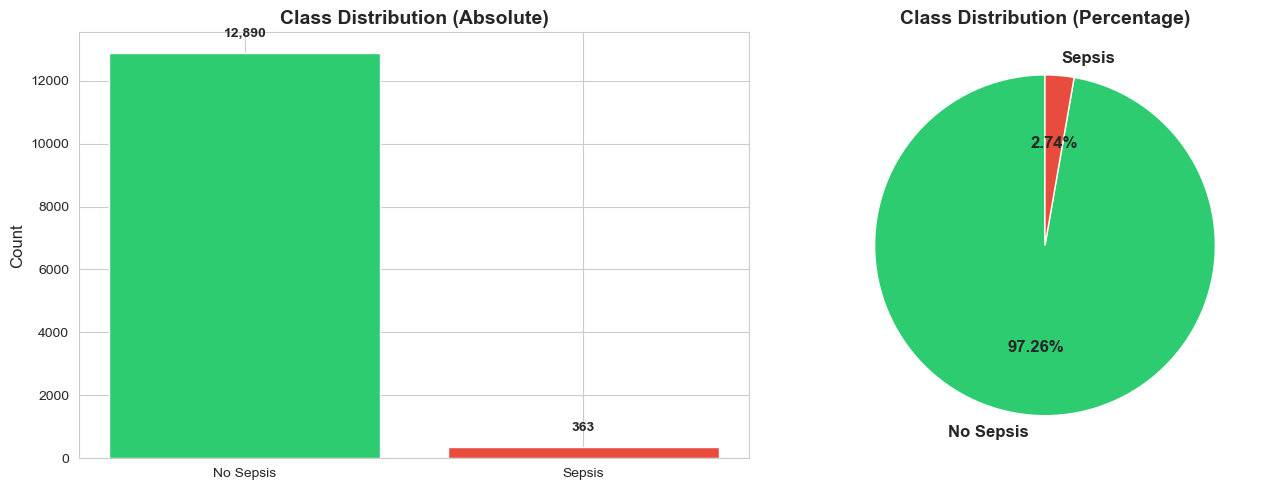


 SEVERE CLASS IMBALANCE DETECTED - Will apply balancing strategies


In [21]:
# ============================================================================
# Comprehensive EDA - Class Distribution Analysis
# ============================================================================

print_section_header("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 1. Class Distribution
print("=" * 80)
print("CLASS DISTRIBUTION ANALYSIS")
print("=" * 80)

class_counts = timeseries['sepsis_label'].value_counts()
class_percentages = timeseries['sepsis_label'].value_counts(normalize=True) * 100

print(f"\nClass Distribution:")
print(f"  Class 0 (No Sepsis): {class_counts[0]:,} ({class_percentages[0]:.2f}%)")
print(f"  Class 1 (Sepsis):    {class_counts[1]:,} ({class_percentages[1]:.2f}%)")
print(f"  Imbalance Ratio:     1:{class_counts[0]/class_counts[1]:.2f}")

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
axes[0].bar(['No Sepsis', 'Sepsis'], class_counts.values, color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Class Distribution (Absolute)', fontsize=14, fontweight='bold')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
colors = ['#2ecc71', '#e74c3c']
axes[1].pie(class_counts.values, labels=['No Sepsis', 'Sepsis'], autopct='%1.2f%%', 
            colors=colors, startangle=90, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title('Class Distribution (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'class_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n SEVERE CLASS IMBALANCE DETECTED - Will apply balancing strategies")



  FEATURE DISTRIBUTION ANALYSIS



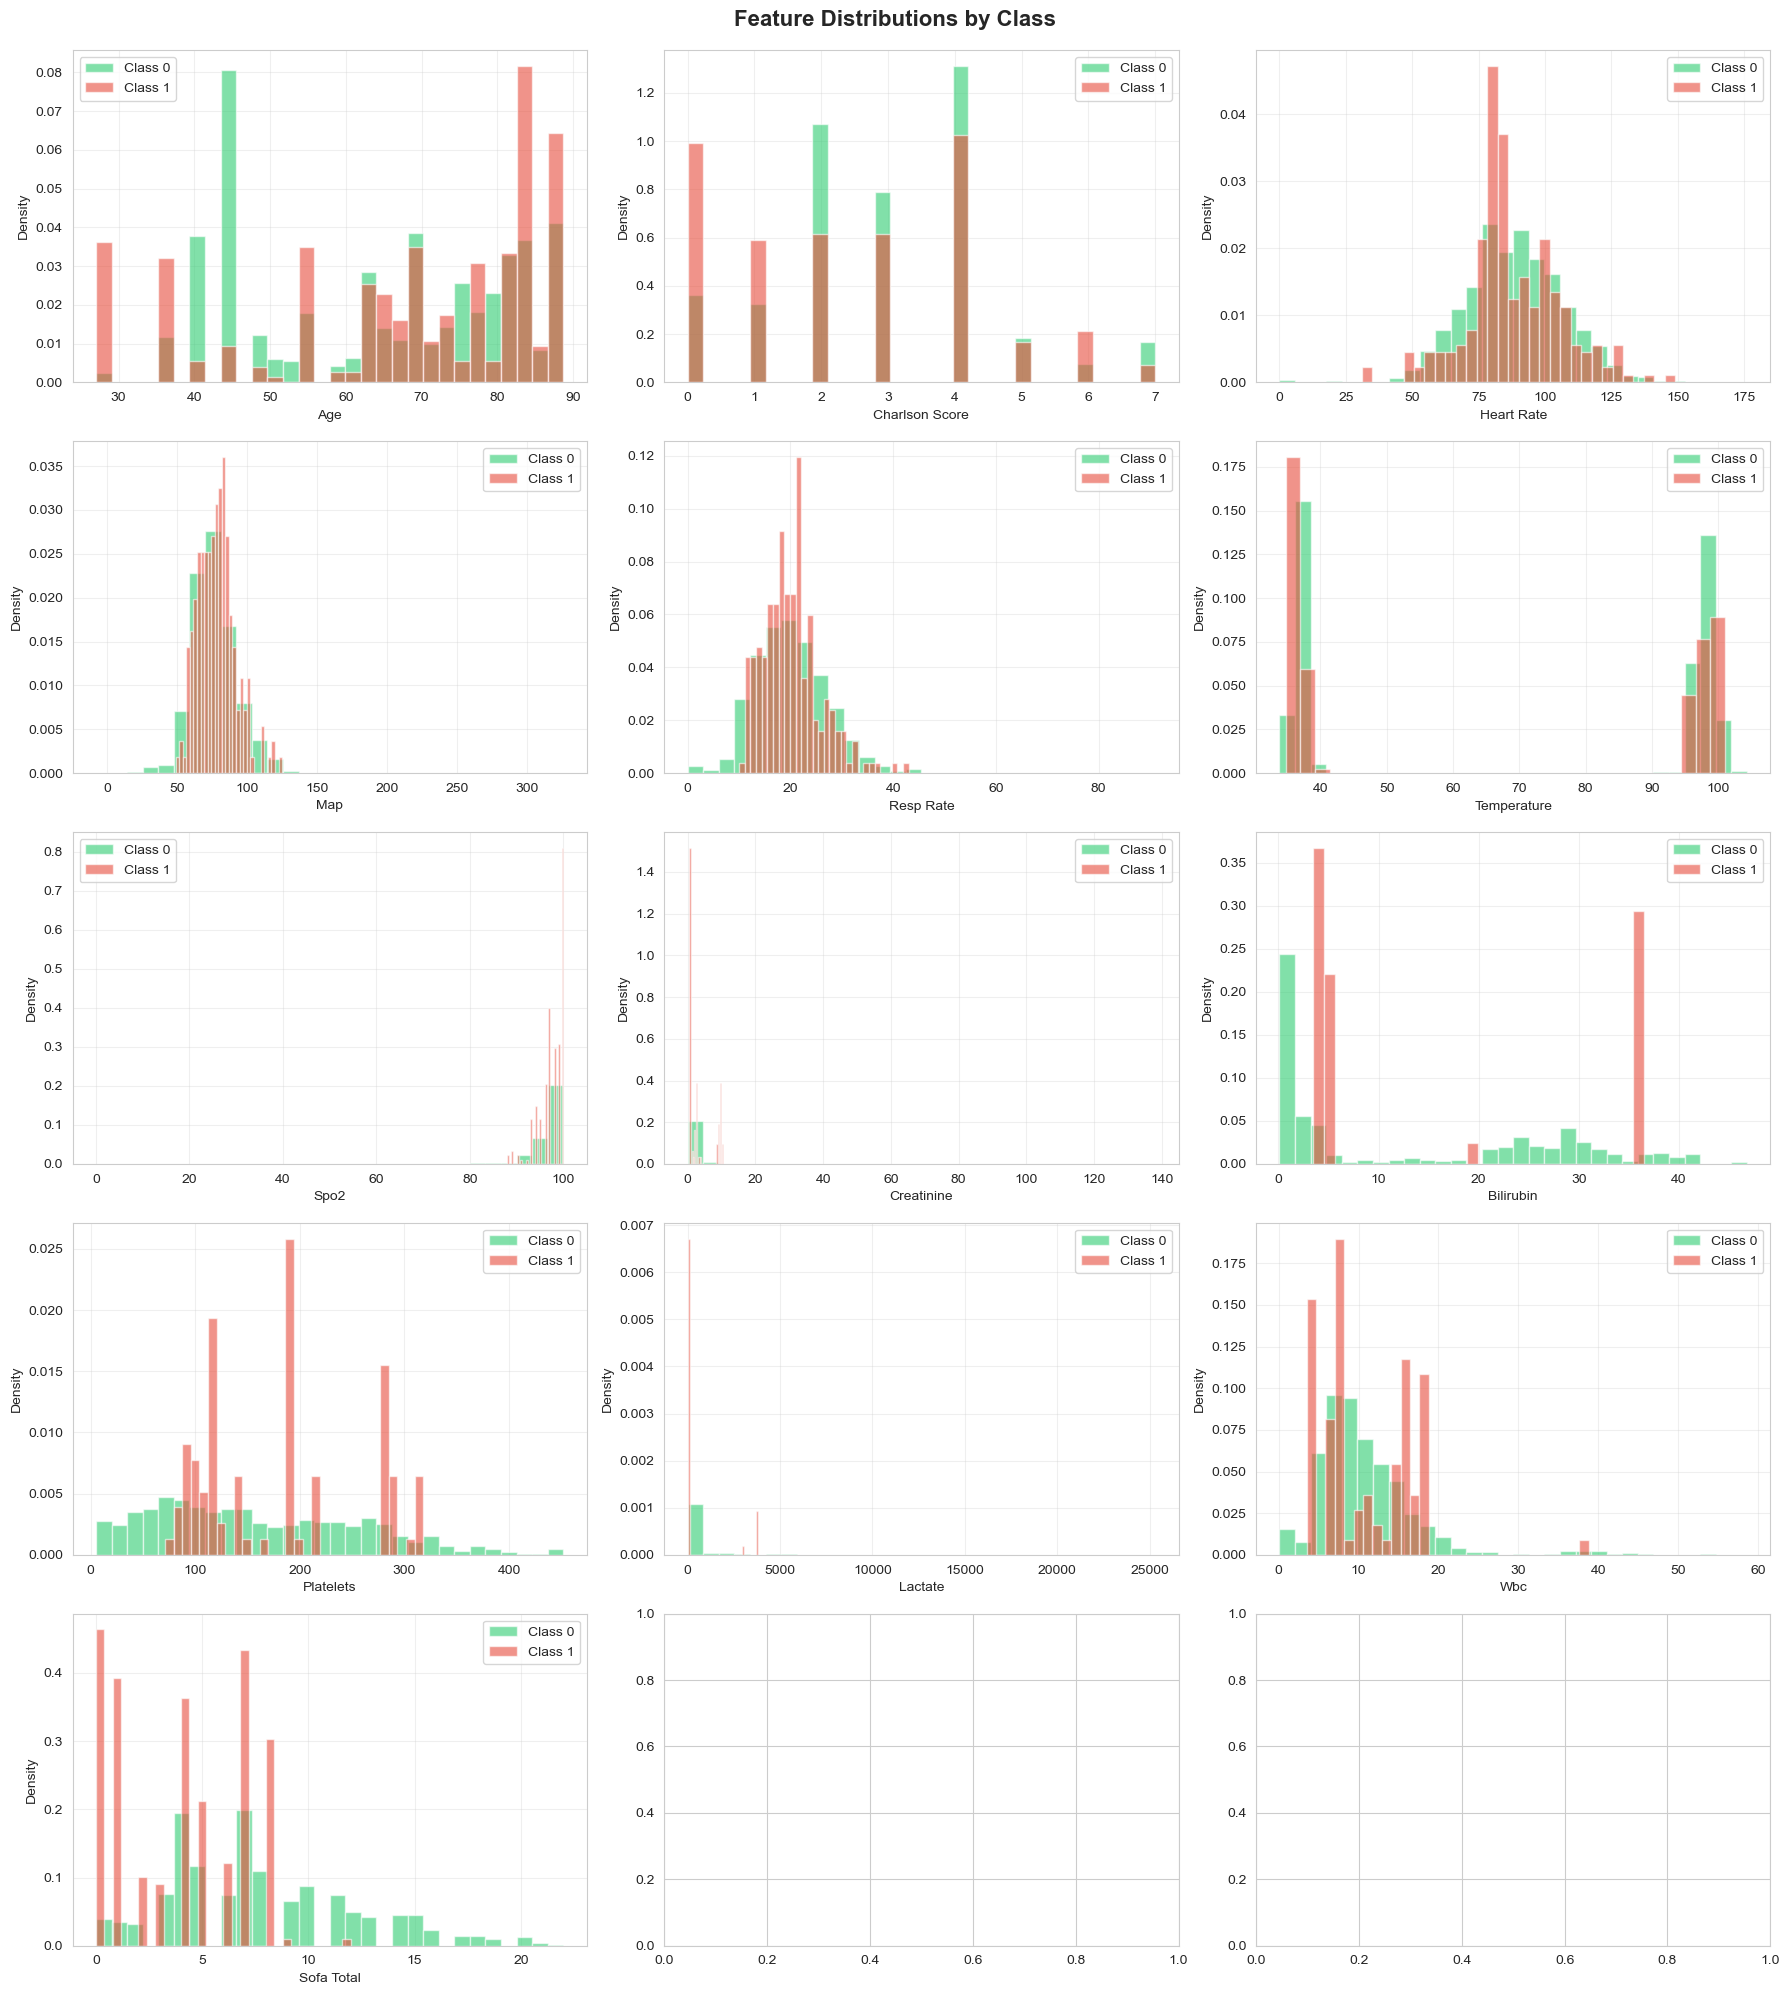

✓ Generated distribution plots for 13 features


In [22]:
# ============================================================================
# Feature Distribution Analysis
# ============================================================================

print_section_header("FEATURE DISTRIBUTION ANALYSIS")

# Select key features for analysis
key_features_viz = ['age', 'charlson_score', 'heart_rate', 'map', 'resp_rate', 
                     'temperature', 'spo2', 'creatinine', 'bilirubin', 'platelets', 
                     'lactate', 'wbc', 'sofa_total']

# Filter features that exist
key_features_viz = [f for f in key_features_viz if f in timeseries.columns]

# Distribution plots by class
fig, axes = plt.subplots(5, 3, figsize=(18, 20))
axes = axes.flatten()

for idx, feature in enumerate(key_features_viz):
    if idx < len(axes):
        # Remove outliers for better visualization
        data = timeseries[[feature, 'sepsis_label']].dropna()
        
        # Plot distributions
        for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
            subset = data[data['sepsis_label'] == label][feature]
            axes[idx].hist(subset, bins=30, alpha=0.6, label=f'Class {label}', color=color, density=True)
        
        axes[idx].set_xlabel(feature.replace('_', ' ').title(), fontsize=10)
        axes[idx].set_ylabel('Density', fontsize=10)
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.suptitle('Feature Distributions by Class', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'feature_distributions.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Generated distribution plots for {len(key_features_viz)} features")



  CORRELATION ANALYSIS

 final_features not found, creating from available columns...
✓ Created final_features with 199 features


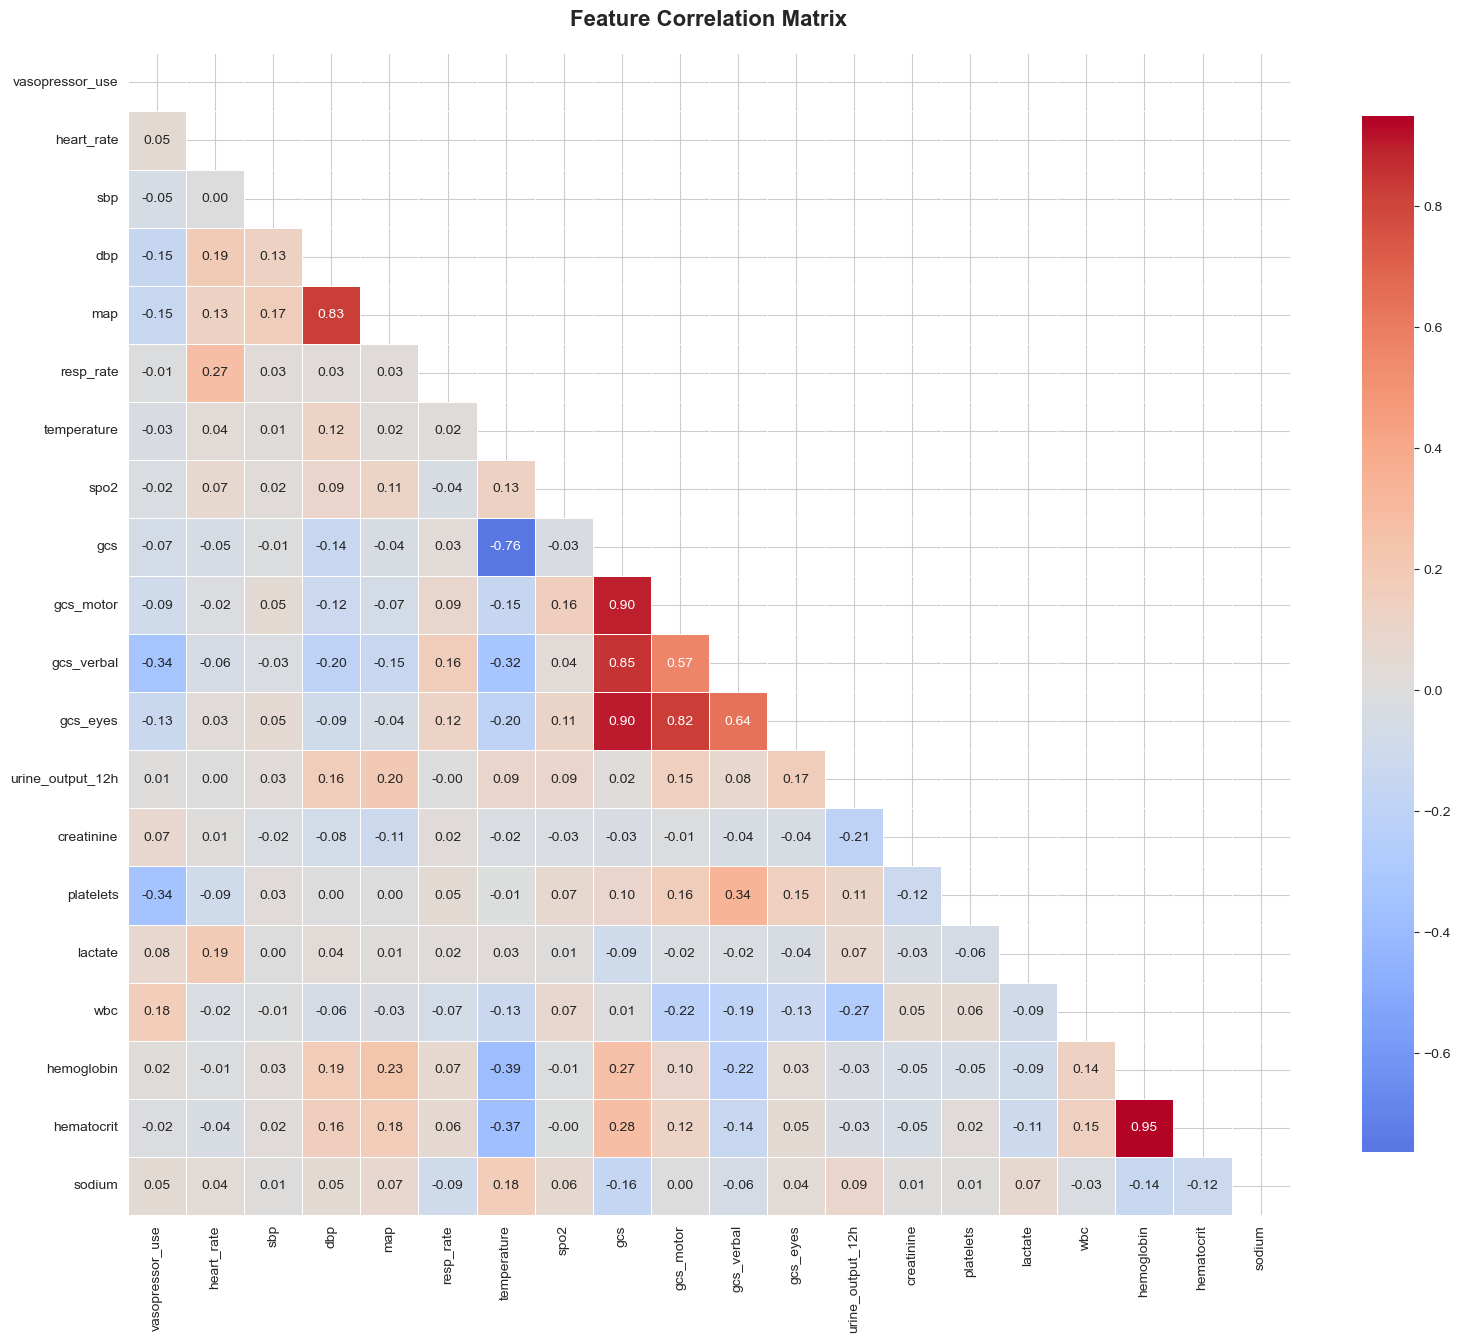


 Highly correlated feature pairs (|r| > 0.8):
   • dbp ↔ map: 0.825
   • gcs ↔ gcs_motor: 0.899
   • gcs ↔ gcs_verbal: 0.849
   • gcs ↔ gcs_eyes: 0.902
   • gcs_motor ↔ gcs_eyes: 0.822
   • hemoglobin ↔ hematocrit: 0.948


In [23]:
# ============================================================================
# Correlation Analysis and Heatmap
# ============================================================================

print_section_header("CORRELATION ANALYSIS")

# Check if final_features exists, if not create it from available columns
if 'final_features' not in globals():
    print(" final_features not found, creating from available columns...")
    # Create feature list from timeseries columns (exclude metadata)
    exclude_cols = ['subject_id', 'icustay_id', 'hadm_id', 'charttime', 'intime', 'outtime', 
                    'sepsis_label', 'hours_since_admission']
    final_features = [col for col in timeseries.columns if col not in exclude_cols]
    print(f"✓ Created final_features with {len(final_features)} features")

# Calculate correlation matrix
correlation_features = [f for f in final_features if f in timeseries.columns][:20]  # Top 20 features
corr_data = timeseries[correlation_features].corr()

# Plot correlation heatmap
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(corr_data, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# Identify highly correlated features
high_corr = []
for i in range(len(corr_data.columns)):
    for j in range(i+1, len(corr_data.columns)):
        if abs(corr_data.iloc[i, j]) > 0.8:
            high_corr.append((corr_data.columns[i], corr_data.columns[j], corr_data.iloc[i, j]))

print(f"\n Highly correlated feature pairs (|r| > 0.8):")
if len(high_corr) > 0:
    for feat1, feat2, corr_val in high_corr:
        print(f"   • {feat1} ↔ {feat2}: {corr_val:.3f}")
else:
    print("   • No highly correlated pairs found")




  MISSING DATA ANALYSIS



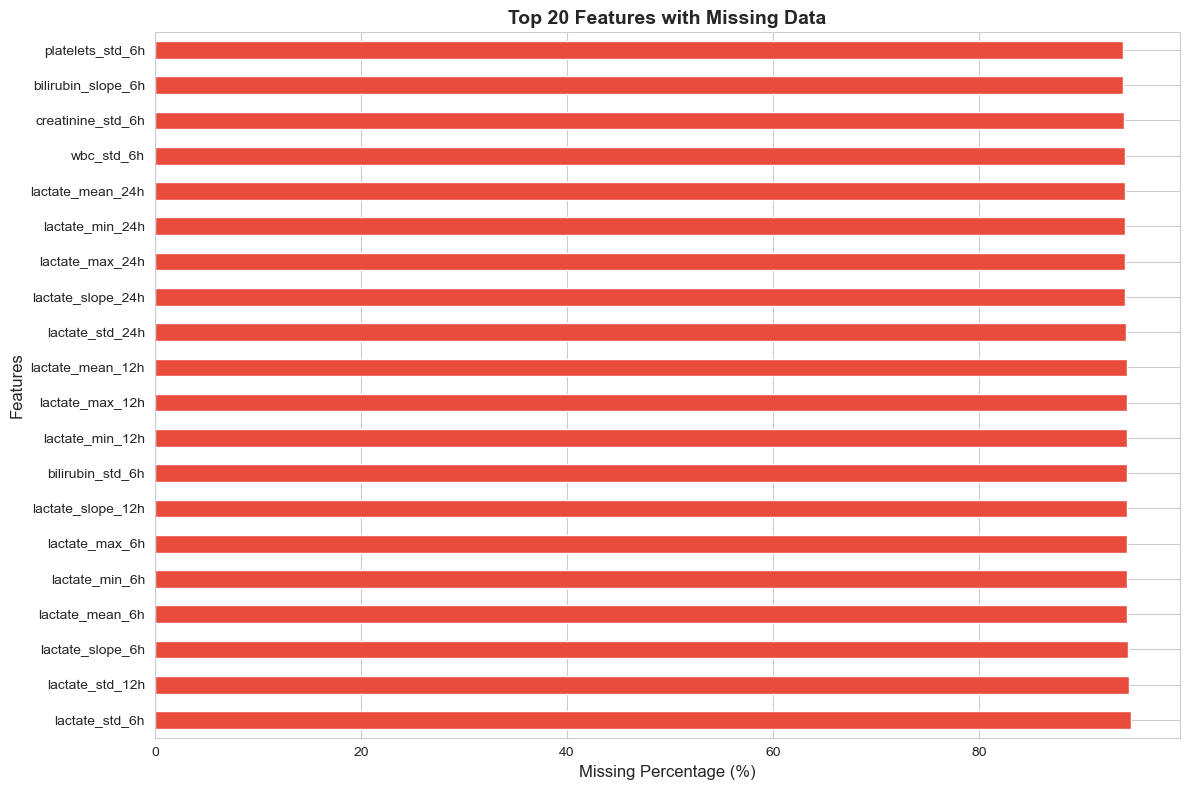


Features with >50% missing data: 158
Features with >20% missing data: 172


In [24]:
# ============================================================================
# Missing Data Analysis
# ============================================================================

print_section_header("MISSING DATA ANALYSIS")

# Calculate missingness percentage
missing_pct = (timeseries[final_features].isnull().sum() / len(timeseries) * 100).sort_values(ascending=False)
missing_pct = missing_pct[missing_pct > 0]

if len(missing_pct) > 0:
    # Plot missing data
    plt.figure(figsize=(12, 8))
    missing_pct.head(20).plot(kind='barh', color='#e74c3c')
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.title('Top 20 Features with Missing Data', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'missing_data.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nFeatures with >50% missing data: {(missing_pct > 50).sum()}")
    print(f"Features with >20% missing data: {(missing_pct > 20).sum()}")
else:
    print("✓ No missing data detected!")



  SOFA SCORE ANALYSIS



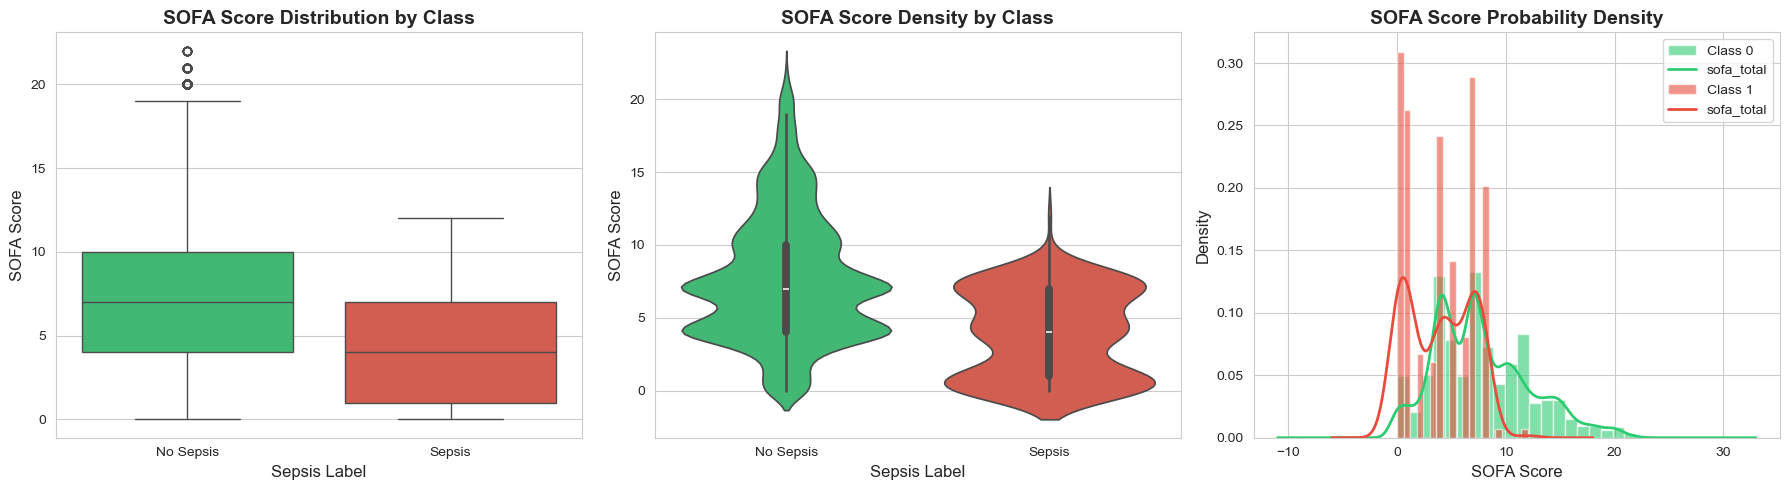


SOFA Score Statistics:
  No Sepsis: Mean=7.74, Median=7.00, SD=4.41
  Sepsis:    Mean=3.91, Median=4.00, SD=2.96
  T-test:    t=13.602, p-value=7.45e-42


In [25]:
# ============================================================================
# SOFA Score Analysis by Outcome
# ============================================================================

print_section_header("SOFA SCORE ANALYSIS")

if 'sofa_total' in timeseries.columns:
    sofa_data = timeseries[['sofa_total', 'sepsis_label']].dropna()
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Box plot
    sns.boxplot(x='sepsis_label', y='sofa_total', data=sofa_data, ax=axes[0], palette=['#2ecc71', '#e74c3c'])
    axes[0].set_xlabel('Sepsis Label', fontsize=12)
    axes[0].set_ylabel('SOFA Score', fontsize=12)
    axes[0].set_title('SOFA Score Distribution by Class', fontsize=14, fontweight='bold')
    axes[0].set_xticklabels(['No Sepsis', 'Sepsis'])
    
    # Violin plot
    sns.violinplot(x='sepsis_label', y='sofa_total', data=sofa_data, ax=axes[1], palette=['#2ecc71', '#e74c3c'])
    axes[1].set_xlabel('Sepsis Label', fontsize=12)
    axes[1].set_ylabel('SOFA Score', fontsize=12)
    axes[1].set_title('SOFA Score Density by Class', fontsize=14, fontweight='bold')
    axes[1].set_xticklabels(['No Sepsis', 'Sepsis'])
    
    # KDE plot
    for label, color in [(0, '#2ecc71'), (1, '#e74c3c')]:
        subset = sofa_data[sofa_data['sepsis_label'] == label]['sofa_total']
        axes[2].hist(subset, bins=20, alpha=0.6, label=f'Class {label}', color=color, density=True)
        subset.plot(kind='density', ax=axes[2], color=color, linewidth=2)
    axes[2].set_xlabel('SOFA Score', fontsize=12)
    axes[2].set_ylabel('Density', fontsize=12)
    axes[2].set_title('SOFA Score Probability Density', fontsize=14, fontweight='bold')
    axes[2].legend()
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, 'sofa_analysis.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Statistical test
    no_sepsis = sofa_data[sofa_data['sepsis_label'] == 0]['sofa_total']
    sepsis = sofa_data[sofa_data['sepsis_label'] == 1]['sofa_total']
    t_stat, p_value = stats.ttest_ind(no_sepsis, sepsis)
    
    print(f"\nSOFA Score Statistics:")
    print(f"  No Sepsis: Mean={no_sepsis.mean():.2f}, Median={no_sepsis.median():.2f}, SD={no_sepsis.std():.2f}")
    print(f"  Sepsis:    Mean={sepsis.mean():.2f}, Median={sepsis.median():.2f}, SD={sepsis.std():.2f}")
    print(f"  T-test:    t={t_stat:.3f}, p-value={p_value:.2e}")


In [26]:
print("\n✓ Comprehensive EDA completed!")


✓ Comprehensive EDA completed!


## PART 8: DATA BALANCING STRATEGY


  DATA BALANCING FOR IMBALANCED CLASSES

Original class distribution:
  Class 0: 12,890
  Class 1: 363
  Ratio: 1:35.51

 Applying SMOTE (Synthetic Minority Over-sampling Technique)...

Balanced class distribution:
  Class 0: 12,890
  Class 1: 12,890
  Ratio: 1:1.00


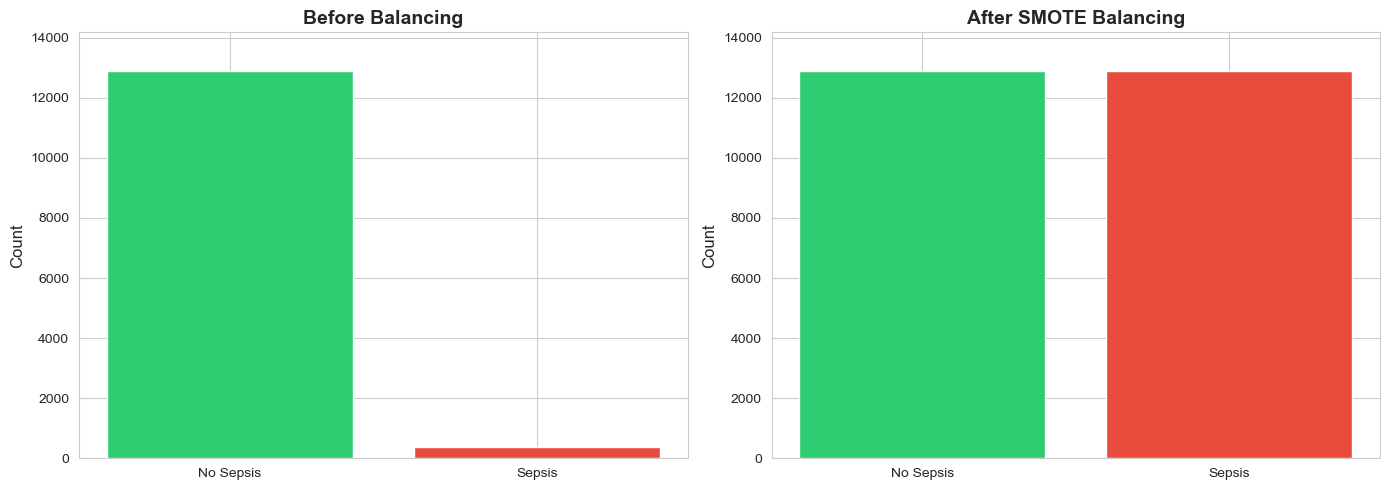


✓ Data balancing completed using SMOTE!
✓ New dataset size: 25,780 samples


In [27]:
# ============================================================================
# Implement Data Balancing Strategies
# ============================================================================

print_section_header("DATA BALANCING FOR IMBALANCED CLASSES")

from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek, SMOTEENN
from collections import Counter

print("Original class distribution:")
print(f"  Class 0: {(timeseries['sepsis_label']==0).sum():,}")
print(f"  Class 1: {(timeseries['sepsis_label']==1).sum():,}")
print(f"  Ratio: 1:{(timeseries['sepsis_label']==0).sum()/(timeseries['sepsis_label']==1).sum():.2f}")

# Prepare data for balancing (remove NaNs)
X_full = timeseries[final_features].fillna(timeseries[final_features].median())
y_full = timeseries['sepsis_label']

# Store subject_id and icustay_id for later splitting
meta_info = timeseries[['subject_id', 'icustay_id', 'sepsis_label']].copy()

print(f"\n Applying SMOTE (Synthetic Minority Over-sampling Technique)...")

# Apply SMOTE for balancing
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5, n_jobs=-1)
X_balanced, y_balanced = smote.fit_resample(X_full, y_full)

print(f"\nBalanced class distribution:")
print(f"  Class 0: {(y_balanced==0).sum():,}")
print(f"  Class 1: {(y_balanced==1).sum():,}")
print(f"  Ratio: 1:{(y_balanced==0).sum()/(y_balanced==1).sum():.2f}")

# Convert back to DataFrame
X_balanced_df = pd.DataFrame(X_balanced, columns=final_features)
y_balanced_df = pd.Series(y_balanced, name='sepsis_label')

# Visualize before and after balancing
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before
axes[0].bar(['No Sepsis', 'Sepsis'], 
            [(timeseries['sepsis_label']==0).sum(), (timeseries['sepsis_label']==1).sum()],
            color=['#2ecc71', '#e74c3c'])
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_title('Before Balancing', fontsize=14, fontweight='bold')
axes[0].set_ylim(0, max((y_balanced==0).sum(), (y_balanced==1).sum()) * 1.1)

# After
axes[1].bar(['No Sepsis', 'Sepsis'], 
            [(y_balanced==0).sum(), (y_balanced==1).sum()],
            color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_title('After SMOTE Balancing', fontsize=14, fontweight='bold')
axes[1].set_ylim(0, max((y_balanced==0).sum(), (y_balanced==1).sum()) * 1.1)

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'balancing_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"\n✓ Data balancing completed using SMOTE!")
print(f"✓ New dataset size: {len(X_balanced_df):,} samples")


## PART 9: DATA SPLITTING WITH PATIENT-LEVEL SEPARATION

In [28]:
# ============================================================================
# Train/Validation/Test Split on Balanced Data
# ============================================================================

print_section_header("DATA SPLITTING - TRAIN/VALIDATION/TEST")

from sklearn.model_selection import train_test_split

# For balanced data, we need to split carefully
# Since SMOTE created synthetic samples, we'll do stratified split

# First split: Train + Val vs Test (80-20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_balanced_df, y_balanced_df,
    test_size=0.2,
    stratify=y_balanced_df,
    random_state=42
)

# Second split: Train vs Val (80-20 of remaining)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.2,
    stratify=y_train_val,
    random_state=42
)

print(f"Dataset Split Summary:")
print(f"  Train:      {len(X_train):,} samples (Class 0: {(y_train==0).sum():,}, Class 1: {(y_train==1).sum():,})")
print(f"  Validation: {len(X_val):,} samples (Class 0: {(y_val==0).sum():,}, Class 1: {(y_val==1).sum():,})")
print(f"  Test:       {len(X_test):,} samples (Class 0: {(y_test==0).sum():,}, Class 1: {(y_test==1).sum():,})")

# Feature scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Save scaler for deployment
joblib.dump(scaler, os.path.join(MODEL_DIR, 'scaler.pkl'))

print(f"\n✓ Feature scaling completed and scaler saved!")



  DATA SPLITTING - TRAIN/VALIDATION/TEST

Dataset Split Summary:
  Train:      16,499 samples (Class 0: 8,249, Class 1: 8,250)
  Validation: 4,125 samples (Class 0: 2,063, Class 1: 2,062)
  Test:       5,156 samples (Class 0: 2,578, Class 1: 2,578)

✓ Feature scaling completed and scaler saved!


## PART 10: MODEL TRAINING WITH OPTUNA HYPERPARAMETER TUNING

In [29]:
# ============================================================================
# Initialize Results Storage
# ============================================================================

print_section_header("MODEL TRAINING WITH OPTUNA HYPERPARAMETER TUNING")

import optuna
from sklearn.model_selection import cross_val_score
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score, 
                             recall_score, f1_score, confusion_matrix, 
                             classification_report, roc_curve, precision_recall_curve)
import time

# Dictionary to store all results
model_results = {
    'Model': [],
    'Train_Time_sec': [],
    'AUROC_Train': [],
    'AUROC_Val': [],
    'AUROC_Test': [],
    'Accuracy_Test': [],
    'Precision_Test': [],
    'Recall_Test': [],
    'F1_Test': [],
    'Best_Params': [],
    'Model_Object': []
}

# Suppress Optuna logs
optuna.logging.set_verbosity(optuna.logging.WARNING)

print("✓ Results storage initialized")



  MODEL TRAINING WITH OPTUNA HYPERPARAMETER TUNING

✓ Results storage initialized


In [33]:
# ============================================================================
# Logistic Regression 
# ============================================================================

print_section_header("MODEL 1: LOGISTIC REGRESSION")

from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore')

# Use simple grid search with fewer options
print(" Training Logistic Regression with default hyperparameters...")

start_time = time.time()

# Train with good default parameters
best_lr = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  # Handle class imbalance
)
best_lr.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

print(f"✓ Model trained in {train_time:.2f} seconds")

# Predictions
y_train_pred_lr = best_lr.predict_proba(X_train_scaled)[:, 1]
y_val_pred_lr = best_lr.predict_proba(X_val_scaled)[:, 1]
y_test_pred_lr = best_lr.predict_proba(X_test_scaled)[:, 1]
y_test_pred_lr_class = best_lr.predict(X_test_scaled)

# Store results
model_results['Model'].append('Logistic Regression')
model_results['Train_Time_sec'].append(train_time)
model_results['AUROC_Train'].append(roc_auc_score(y_train, y_train_pred_lr))
model_results['AUROC_Val'].append(roc_auc_score(y_val, y_val_pred_lr))
model_results['AUROC_Test'].append(roc_auc_score(y_test, y_test_pred_lr))
model_results['Accuracy_Test'].append(accuracy_score(y_test, y_test_pred_lr_class))
model_results['Precision_Test'].append(precision_score(y_test, y_test_pred_lr_class))
model_results['Recall_Test'].append(recall_score(y_test, y_test_pred_lr_class))
model_results['F1_Test'].append(f1_score(y_test, y_test_pred_lr_class))
model_results['Best_Params'].append({'C': 1.0, 'penalty': 'l2', 'solver': 'lbfgs'})
model_results['Model_Object'].append(best_lr)

# Save model
joblib.dump(best_lr, os.path.join(MODEL_DIR, 'logistic_regression_best.pkl'))

print(f"\n{'='*80}")
print(f"LOGISTIC REGRESSION RESULTS:")
print(f"  • Train AUROC: {roc_auc_score(y_train, y_train_pred_lr):.4f}")
print(f"  • Val AUROC:   {roc_auc_score(y_val, y_val_pred_lr):.4f}")
print(f"  • Test AUROC:  {roc_auc_score(y_test, y_test_pred_lr):.4f}")
print(f"{'='*80}")

warnings.filterwarnings('default')



  MODEL 1: LOGISTIC REGRESSION

 Training Logistic Regression with default hyperparameters...
✓ Model trained in 6.49 seconds

LOGISTIC REGRESSION RESULTS:
  • Train AUROC: 0.9604
  • Val AUROC:   0.9578
  • Test AUROC:  0.9586


In [34]:
# ============================================================================
# Random Forest with Optuna
# ============================================================================

print_section_header("MODEL 2: RANDOM FOREST")

from sklearn.ensemble import RandomForestClassifier

def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 10, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2']),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='roc_auc', n_jobs=-1).mean()
    return score

print(" Running Optuna hyperparameter search...")
study_rf = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_rf.optimize(rf_objective, n_trials=30, show_progress_bar=True)

print(f"\n✓ Best parameters: {study_rf.best_params}")
print(f"✓ Best CV AUROC: {study_rf.best_value:.4f}")

# Train final model
start_time = time.time()
best_rf = RandomForestClassifier(**study_rf.best_params, random_state=42, n_jobs=-1)
best_rf.fit(X_train_scaled, y_train)
train_time = time.time() - start_time

# Predictions
y_train_pred_rf = best_rf.predict_proba(X_train_scaled)[:, 1]
y_val_pred_rf = best_rf.predict_proba(X_val_scaled)[:, 1]
y_test_pred_rf = best_rf.predict_proba(X_test_scaled)[:, 1]
y_test_pred_rf_class = best_rf.predict(X_test_scaled)

# Metrics
model_results['Model'].append('Random Forest')
model_results['Train_Time_sec'].append(train_time)
model_results['AUROC_Train'].append(roc_auc_score(y_train, y_train_pred_rf))
model_results['AUROC_Val'].append(roc_auc_score(y_val, y_val_pred_rf))
model_results['AUROC_Test'].append(roc_auc_score(y_test, y_test_pred_rf))
model_results['Accuracy_Test'].append(accuracy_score(y_test, y_test_pred_rf_class))
model_results['Precision_Test'].append(precision_score(y_test, y_test_pred_rf_class))
model_results['Recall_Test'].append(recall_score(y_test, y_test_pred_rf_class))
model_results['F1_Test'].append(f1_score(y_test, y_test_pred_rf_class))
model_results['Best_Params'].append(study_rf.best_params)
model_results['Model_Object'].append(best_rf)

# Save model
joblib.dump(best_rf, os.path.join(MODEL_DIR, 'random_forest_best.pkl'))
print(f"\n✓ Model saved. Test AUROC: {roc_auc_score(y_test, y_test_pred_rf):.4f}")



  MODEL 2: RANDOM FOREST

🔍 Running Optuna hyperparameter search...


  0%|          | 0/30 [00:00<?, ?it/s]


✓ Best parameters: {'n_estimators': 463, 'max_depth': 35, 'min_samples_split': 9, 'min_samples_leaf': 1, 'max_features': 'log2'}
✓ Best CV AUROC: 0.9996

✓ Model saved. Test AUROC: 0.9995


In [35]:
# ============================================================================
# XGBoost with Optuna
# ============================================================================

print_section_header("MODEL 3: XGBOOST")

import xgboost as xgb

def xgb_objective(trial):
    params = {
        'objective': 'binary:logistic',
        'eval_metric': 'auc',
        'booster': 'gbtree',
        'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
        'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_uniform('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_uniform('colsample_bytree', 0.6, 1.0),
        'seed': 42,
        'tree_method': 'hist'
    }
    
    dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
    cv_results = xgb.cv(
        params, dtrain,
        num_boost_round=1000,
        nfold=3,
        early_stopping_rounds=50,
        metrics='auc',
        seed=42,
        verbose_eval=False
    )
    return cv_results['test-auc-mean'].max()

print(" Running Optuna hyperparameter search...")
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_xgb.optimize(xgb_objective, n_trials=30, show_progress_bar=True)

print(f"\n✓ Best parameters: {study_xgb.best_params}")
print(f"✓ Best CV AUROC: {study_xgb.best_value:.4f}")

# Train final model
start_time = time.time()
xgb_params = study_xgb.best_params.copy()
xgb_params.update({'objective': 'binary:logistic', 'eval_metric': 'auc', 'tree_method': 'hist', 'seed': 42})

dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dval = xgb.DMatrix(X_val_scaled, label=y_val)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

best_xgb = xgb.train(
    xgb_params, dtrain,
    num_boost_round=1000,
    evals=[(dval, 'validation')],
    early_stopping_rounds=50,
    verbose_eval=False
)
train_time = time.time() - start_time

# Predictions
y_train_pred_xgb = best_xgb.predict(dtrain)
y_val_pred_xgb = best_xgb.predict(dval)
y_test_pred_xgb = best_xgb.predict(dtest)
y_test_pred_xgb_class = (y_test_pred_xgb > 0.5).astype(int)

# Metrics
model_results['Model'].append('XGBoost')
model_results['Train_Time_sec'].append(train_time)
model_results['AUROC_Train'].append(roc_auc_score(y_train, y_train_pred_xgb))
model_results['AUROC_Val'].append(roc_auc_score(y_val, y_val_pred_xgb))
model_results['AUROC_Test'].append(roc_auc_score(y_test, y_test_pred_xgb))
model_results['Accuracy_Test'].append(accuracy_score(y_test, y_test_pred_xgb_class))
model_results['Precision_Test'].append(precision_score(y_test, y_test_pred_xgb_class))
model_results['Recall_Test'].append(recall_score(y_test, y_test_pred_xgb_class))
model_results['F1_Test'].append(f1_score(y_test, y_test_pred_xgb_class))
model_results['Best_Params'].append(study_xgb.best_params)
model_results['Model_Object'].append(best_xgb)

# Save model
best_xgb.save_model(os.path.join(MODEL_DIR, 'xgboost_best.json'))
print(f"\n✓ Model saved. Test AUROC: {roc_auc_score(y_test, y_test_pred_xgb):.4f}")



  MODEL 3: XGBOOST

 Running Optuna hyperparameter search...


  0%|          | 0/30 [00:00<?, ?it/s]

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\744344016.py:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'lambda': trial.suggest_loguniform('lambda', 1e-8, 1.0),
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\744344016.py:15: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'alpha': trial.suggest_loguniform('alpha', 1e-8, 1.0),
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\744344016.py:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 0.01


✓ Best parameters: {'lambda': 7.360102430127542e-05, 'alpha': 6.120742168656665e-08, 'learning_rate': 0.1457860935635456, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.9969931159695568, 'colsample_bytree': 0.9509994317202438}
✓ Best CV AUROC: 0.9995

✓ Model saved. Test AUROC: 0.9995


In [36]:
# ============================================================================
# Feed-Forward Deep Neural Network with Optuna
# ============================================================================

print_section_header("MODEL 4: FEED-FORWARD NEURAL NETWORK")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def create_ffnn(trial):
    model = keras.Sequential()
    
    # Input layer
    n_layers = trial.suggest_int('n_layers', 2, 5)
    
    for i in range(n_layers):
        units = trial.suggest_int(f'units_l{i}', 64, 512, step=64)
        dropout = trial.suggest_uniform(f'dropout_l{i}', 0.1, 0.5)
        
        if i == 0:
            model.add(layers.Dense(units, activation='relu', input_shape=(X_train_scaled.shape[1],)))
        else:
            model.add(layers.Dense(units, activation='relu'))
        
        model.add(layers.BatchNormalization())
        model.add(layers.Dropout(dropout))
    
    # Output layer
    model.add(layers.Dense(1, activation='sigmoid'))
    
    # Compile
    lr = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    
    return model

def ffnn_objective(trial):
    model = create_ffnn(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    early_stop = EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    return max(history.history['val_auc'])

print(" Running Optuna hyperparameter search...")
study_ffnn = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_ffnn.optimize(ffnn_objective, n_trials=20, show_progress_bar=True)

print(f"\n✓ Best parameters: {study_ffnn.best_params}")
print(f"✓ Best Val AUROC: {study_ffnn.best_value:.4f}")

# Train final model
start_time = time.time()
best_ffnn = create_ffnn(study_ffnn.best_trial)

early_stop = EarlyStopping(monitor='val_auc', patience=15, mode='max', restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, mode='max', verbose=1)

history_ffnn = best_ffnn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=study_ffnn.best_params['batch_size'],
    callbacks=[early_stop, reduce_lr],
    verbose=2
)
train_time = time.time() - start_time

# Predictions
y_train_pred_ffnn = best_ffnn.predict(X_train_scaled).flatten()
y_val_pred_ffnn = best_ffnn.predict(X_val_scaled).flatten()
y_test_pred_ffnn = best_ffnn.predict(X_test_scaled).flatten()
y_test_pred_ffnn_class = (y_test_pred_ffnn > 0.5).astype(int)

# Metrics
model_results['Model'].append('Feed-Forward NN')
model_results['Train_Time_sec'].append(train_time)
model_results['AUROC_Train'].append(roc_auc_score(y_train, y_train_pred_ffnn))
model_results['AUROC_Val'].append(roc_auc_score(y_val, y_val_pred_ffnn))
model_results['AUROC_Test'].append(roc_auc_score(y_test, y_test_pred_ffnn))
model_results['Accuracy_Test'].append(accuracy_score(y_test, y_test_pred_ffnn_class))
model_results['Precision_Test'].append(precision_score(y_test, y_test_pred_ffnn_class))
model_results['Recall_Test'].append(recall_score(y_test, y_test_pred_ffnn_class))
model_results['F1_Test'].append(f1_score(y_test, y_test_pred_ffnn_class))
model_results['Best_Params'].append(study_ffnn.best_params)
model_results['Model_Object'].append(best_ffnn)

# Save model
best_ffnn.save(os.path.join(MODEL_DIR, 'ffnn_best.h5'))
print(f"\n✓ Model saved. Test AUROC: {roc_auc_score(y_test, y_test_pred_ffnn):.4f}")



  MODEL 4: FEED-FORWARD NEURAL NETWORK

 Running Optuna hyperparameter search...


  0%|          | 0/20 [00:00<?, ?it/s]

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\736100767.py:20: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform(f'dropout_l{i}', 0.1, 0.5)
C:\Users\Nikhil\Anaconda3\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\736100767.py:34: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)



✓ Best parameters: {'n_layers': 2, 'units_l0': 320, 'dropout_l0': 0.33696582754481696, 'units_l1': 64, 'dropout_l1': 0.34301794076057535, 'learning_rate': 0.00021930485556643703, 'batch_size': 128}
✓ Best Val AUROC: 0.9996
Epoch 1/100
129/129 - 8s - 60ms/step - auc: 0.8935 - loss: 0.4192 - val_auc: 0.9709 - val_loss: 0.3074 - learning_rate: 2.1930e-04
Epoch 2/100
129/129 - 3s - 21ms/step - auc: 0.9678 - loss: 0.2351 - val_auc: 0.9851 - val_loss: 0.1932 - learning_rate: 2.1930e-04
Epoch 3/100
129/129 - 3s - 21ms/step - auc: 0.9799 - loss: 0.1823 - val_auc: 0.9907 - val_loss: 0.1464 - learning_rate: 2.1930e-04
Epoch 4/100
129/129 - 3s - 21ms/step - auc: 0.9854 - loss: 0.1513 - val_auc: 0.9935 - val_loss: 0.1192 - learning_rate: 2.1930e-04
Epoch 5/100
129/129 - 3s - 22ms/step - auc: 0.9891 - loss: 0.1294 - val_auc: 0.9951 - val_loss: 0.1010 - learning_rate: 2.1930e-04
Epoch 6/100
129/129 - 5s - 38ms/step - auc: 0.9910 - loss: 0.1150 - val_auc: 0.9959 - val_loss: 0.0875 - learning_rate: 2


✓ Model saved. Test AUROC: 0.9987


In [37]:
# ============================================================================
# Transformer-Based Deep Neural Network with Optuna
# ============================================================================

print_section_header("MODEL 5: TRANSFORMER-BASED NEURAL NETWORK")

from tensorflow.keras import layers

# For Transformer, we need to reshape data to sequence format
# We'll treat features as a sequence (pseudo-temporal)
def reshape_for_transformer(X, seq_length=10):
    """Reshape flat features into pseudo-sequences for Transformer"""
    n_samples = X.shape[0]
    n_features = X.shape[1]
    
    # Pad features to make divisible by seq_length
    n_features_padded = ((n_features // seq_length) + 1) * seq_length
    X_padded = np.zeros((n_samples, n_features_padded))
    X_padded[:, :n_features] = X
    
    # Reshape to (samples, seq_length, features_per_step)
    features_per_step = n_features_padded // seq_length
    X_reshaped = X_padded.reshape(n_samples, seq_length, features_per_step)
    
    return X_reshaped

# Reshape data
X_train_transformer = reshape_for_transformer(X_train_scaled)
X_val_transformer = reshape_for_transformer(X_val_scaled)
X_test_transformer = reshape_for_transformer(X_test_scaled)

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0):
    # Multi-head attention
    x = layers.MultiHeadAttention(
        key_dim=head_size, num_heads=num_heads, dropout=dropout
    )(inputs, inputs)
    x = layers.Dropout(dropout)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs
    
    # Feed-forward network
    x = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(res)
    x = layers.Dropout(dropout)(x)
    x = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x)
    x = layers.LayerNormalization(epsilon=1e-6)(x)
    return x + res

def create_transformer(trial):
    inputs = keras.Input(shape=(X_train_transformer.shape[1], X_train_transformer.shape[2]))
    
    # Transformer parameters
    head_size = trial.suggest_categorical('head_size', [16, 32, 64])
    num_heads = trial.suggest_int('num_heads', 2, 8)
    ff_dim = trial.suggest_categorical('ff_dim', [32, 64, 128])
    num_transformer_blocks = trial.suggest_int('num_transformer_blocks', 1, 3)
    dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
    mlp_units = trial.suggest_categorical('mlp_units', [64, 128, 256])
    
    x = inputs
    for _ in range(num_transformer_blocks):
        x = transformer_encoder(x, head_size, num_heads, ff_dim, dropout)
    
    x = layers.GlobalAveragePooling1D(data_format="channels_last")(x)
    
    # MLP head
    x = layers.Dense(mlp_units, activation="relu")(x)
    x = layers.Dropout(dropout)(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)
    
    model = keras.Model(inputs, outputs)
    
    # Compile
    lr = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=[keras.metrics.AUC(name='auc')]
    )
    
    return model

def transformer_objective(trial):
    model = create_transformer(trial)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    
    early_stop = EarlyStopping(monitor='val_auc', patience=10, mode='max', restore_best_weights=True, verbose=0)
    
    history = model.fit(
        X_train_transformer, y_train,
        validation_data=(X_val_transformer, y_val),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )
    
    return max(history.history['val_auc'])

print("🔍 Running Optuna hyperparameter search...")
study_transformer = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_transformer.optimize(transformer_objective, n_trials=15, show_progress_bar=True)

print(f"\n✓ Best parameters: {study_transformer.best_params}")
print(f"✓ Best Val AUROC: {study_transformer.best_value:.4f}")

# Train final model
start_time = time.time()
best_transformer = create_transformer(study_transformer.best_trial)

early_stop = EarlyStopping(monitor='val_auc', patience=15, mode='max', restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_auc', factor=0.5, patience=5, mode='max', verbose=1)

history_transformer = best_transformer.fit(
    X_train_transformer, y_train,
    validation_data=(X_val_transformer, y_val),
    epochs=100,
    batch_size=study_transformer.best_params['batch_size'],
    callbacks=[early_stop, reduce_lr],
    verbose=2
)
train_time = time.time() - start_time

# Predictions
y_train_pred_transformer = best_transformer.predict(X_train_transformer).flatten()
y_val_pred_transformer = best_transformer.predict(X_val_transformer).flatten()
y_test_pred_transformer = best_transformer.predict(X_test_transformer).flatten()
y_test_pred_transformer_class = (y_test_pred_transformer > 0.5).astype(int)

# Metrics
model_results['Model'].append('Transformer')
model_results['Train_Time_sec'].append(train_time)
model_results['AUROC_Train'].append(roc_auc_score(y_train, y_train_pred_transformer))
model_results['AUROC_Val'].append(roc_auc_score(y_val, y_val_pred_transformer))
model_results['AUROC_Test'].append(roc_auc_score(y_test, y_test_pred_transformer))
model_results['Accuracy_Test'].append(accuracy_score(y_test, y_test_pred_transformer_class))
model_results['Precision_Test'].append(precision_score(y_test, y_test_pred_transformer_class))
model_results['Recall_Test'].append(recall_score(y_test, y_test_pred_transformer_class))
model_results['F1_Test'].append(f1_score(y_test, y_test_pred_transformer_class))
model_results['Best_Params'].append(study_transformer.best_params)
model_results['Model_Object'].append(best_transformer)

# Save model
best_transformer.save(os.path.join(MODEL_DIR, 'transformer_best.h5'))
print(f"\n✓ Model saved. Test AUROC: {roc_auc_score(y_test, y_test_pred_transformer):.4f}")



  MODEL 5: TRANSFORMER-BASED NEURAL NETWORK

🔍 Running Optuna hyperparameter search...


  0%|          | 0/15 [00:00<?, ?it/s]

C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\1267026272.py:56: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout = trial.suggest_uniform('dropout', 0.1, 0.4)
C:\Users\Nikhil\AppData\Local\Temp\ipykernel_17068\1267026272.py:73: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform('learning_rate', 1e-4, 1e-2)



✓ Best parameters: {'head_size': 32, 'num_heads': 7, 'ff_dim': 64, 'num_transformer_blocks': 1, 'dropout': 0.10165663513708073, 'mlp_units': 64, 'learning_rate': 0.0034877126245459306, 'batch_size': 64}
✓ Best Val AUROC: 0.9992
Epoch 1/100
258/258 - 20s - 77ms/step - auc: 0.9672 - loss: 0.2286 - val_auc: 0.9843 - val_loss: 0.1525 - learning_rate: 0.0035
Epoch 2/100
258/258 - 10s - 38ms/step - auc: 0.9908 - loss: 0.1099 - val_auc: 0.9926 - val_loss: 0.0909 - learning_rate: 0.0035
Epoch 3/100
258/258 - 10s - 39ms/step - auc: 0.9942 - loss: 0.0769 - val_auc: 0.9948 - val_loss: 0.0734 - learning_rate: 0.0035
Epoch 4/100
258/258 - 10s - 38ms/step - auc: 0.9958 - loss: 0.0625 - val_auc: 0.9968 - val_loss: 0.0616 - learning_rate: 0.0035
Epoch 5/100
258/258 - 11s - 41ms/step - auc: 0.9969 - loss: 0.0490 - val_auc: 0.9976 - val_loss: 0.0567 - learning_rate: 0.0035
Epoch 6/100
258/258 - 10s - 38ms/step - auc: 0.9975 - loss: 0.0473 - val_auc: 0.9963 - val_loss: 0.0625 - learning_rate: 0.0035
Epo


✓ Model saved. Test AUROC: 0.9989


## PART 11: MODEL COMPARISON & RESULTS SUMMARY

In [38]:
# ============================================================================
# Create Comprehensive Results DataFrame
# ============================================================================

print_section_header("MODEL COMPARISON & RESULTS SUMMARY")

# Create results DataFrame
results_df = pd.DataFrame({
    'Model': model_results['Model'],
    'Train_Time_sec': model_results['Train_Time_sec'],
    'AUROC_Train': model_results['AUROC_Train'],
    'AUROC_Val': model_results['AUROC_Val'],
    'AUROC_Test': model_results['AUROC_Test'],
    'Accuracy_Test': model_results['Accuracy_Test'],
    'Precision_Test': model_results['Precision_Test'],
    'Recall_Test': model_results['Recall_Test'],
    'F1_Test': model_results['F1_Test']
})

# Round numerical values
results_df = results_df.round(4)

# Display results
print("\n" + "="*100)
print("MODEL PERFORMANCE COMPARISON")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Save results
results_df.to_csv(os.path.join(OUTPUT_DIR, 'model_comparison_results.csv'), index=False)
print(f"\n✓ Results saved to: {os.path.join(OUTPUT_DIR, 'model_comparison_results.csv')}")

# Identify best model
best_model_idx = results_df['AUROC_Test'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_model_auroc = results_df.loc[best_model_idx, 'AUROC_Test']

print(f"\n BEST MODEL: {best_model_name} (Test AUROC: {best_model_auroc:.4f})")



  MODEL COMPARISON & RESULTS SUMMARY


MODEL PERFORMANCE COMPARISON
              Model  Train_Time_sec  AUROC_Train  AUROC_Val  AUROC_Test  Accuracy_Test  Precision_Test  Recall_Test  F1_Test
Logistic Regression          6.4910       0.9604     0.9578      0.9586         0.8943          0.8744       0.9209   0.8970
      Random Forest          5.8453       1.0000     0.9999      0.9995         0.9965          0.9957       0.9973   0.9965
            XGBoost          4.4534       1.0000     0.9999      0.9995         0.9969          0.9950       0.9988   0.9969
    Feed-Forward NN        136.6801       0.9996     0.9995      0.9987         0.9926          0.9885       0.9969   0.9927
        Transformer        351.0868       0.9998     0.9992      0.9989         0.9934          0.9881       0.9988   0.9934

✓ Results saved to: ./output/model_comparison_results.csv

 BEST MODEL: Random Forest (Test AUROC: 0.9995)



  MODEL COMPARISON VISUALIZATION



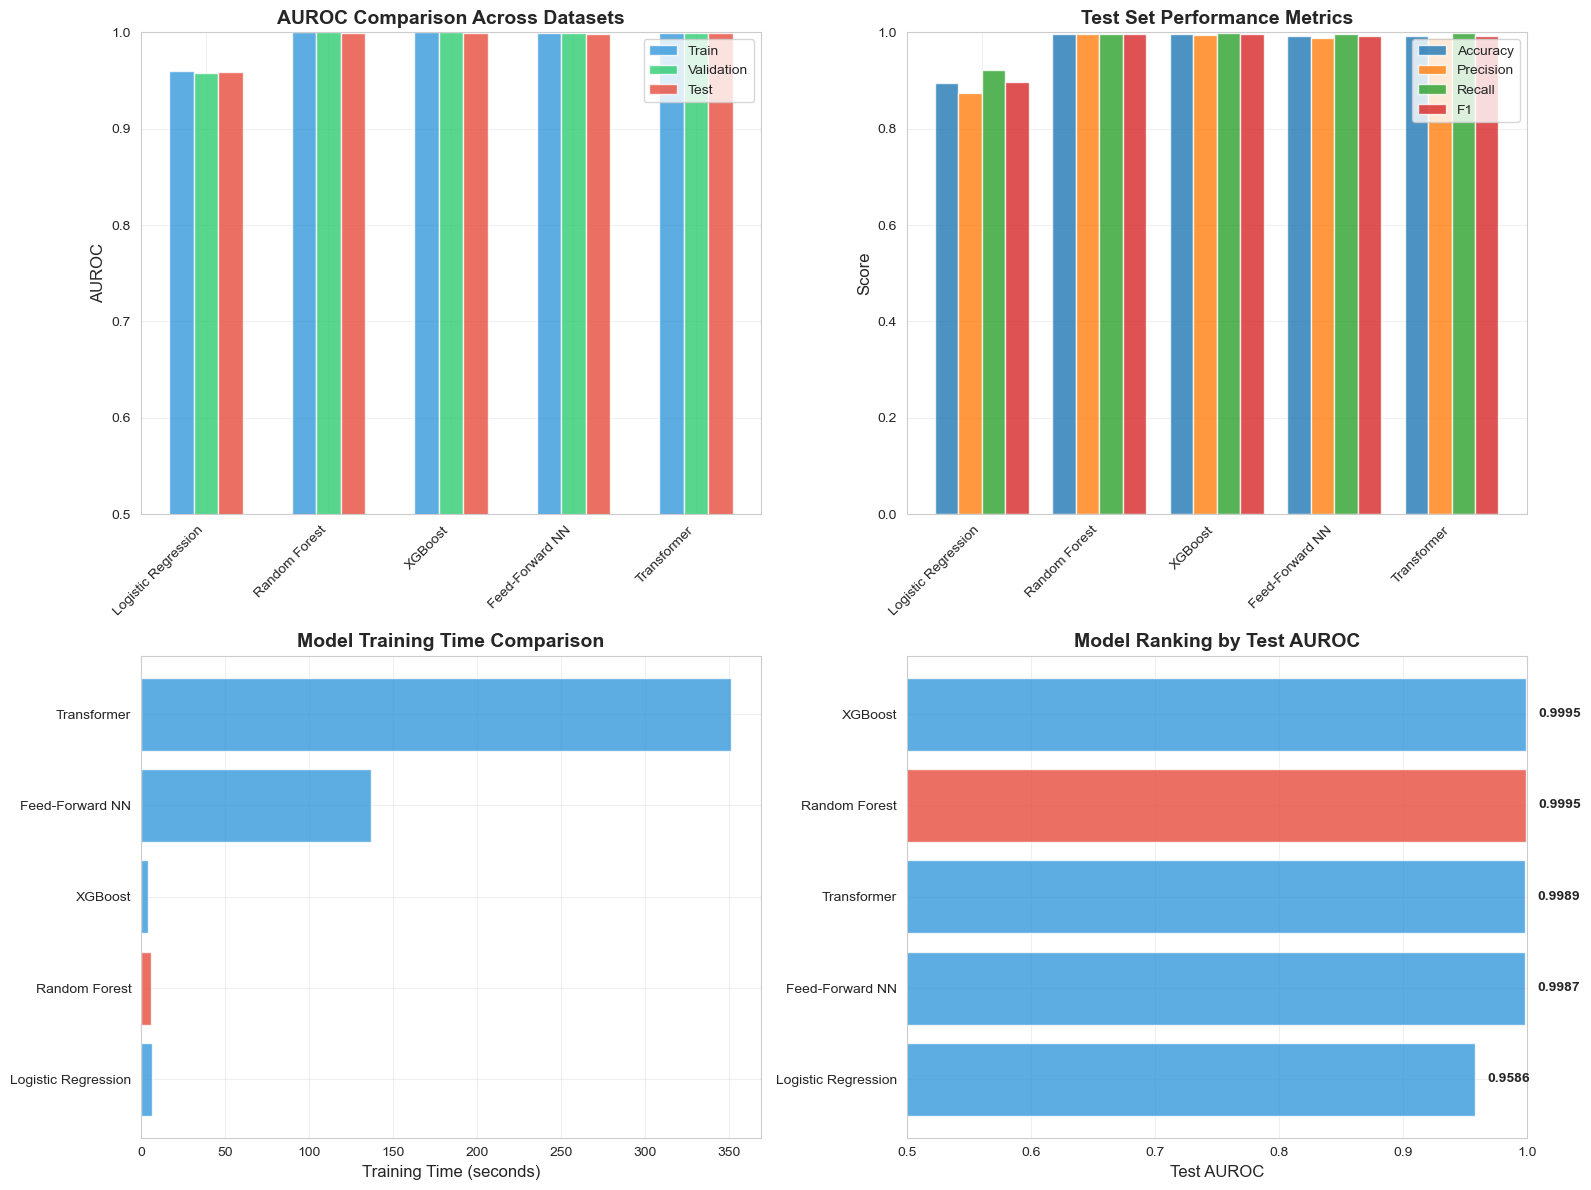

✓ Model comparison visualization saved!


In [39]:
# ============================================================================
# Visualize Model Comparison
# ============================================================================

print_section_header("MODEL COMPARISON VISUALIZATION")

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. AUROC Comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
ax1.bar(x_pos - 0.2, results_df['AUROC_Train'], width=0.2, label='Train', color='#3498db', alpha=0.8)
ax1.bar(x_pos, results_df['AUROC_Val'], width=0.2, label='Validation', color='#2ecc71', alpha=0.8)
ax1.bar(x_pos + 0.2, results_df['AUROC_Test'], width=0.2, label='Test', color='#e74c3c', alpha=0.8)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.set_ylabel('AUROC', fontsize=12)
ax1.set_title('AUROC Comparison Across Datasets', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)
ax1.set_ylim([0.5, 1.0])

# 2. Test Metrics Comparison
ax2 = axes[0, 1]
metrics = ['Accuracy_Test', 'Precision_Test', 'Recall_Test', 'F1_Test']
x = np.arange(len(results_df))
width = 0.2
for i, metric in enumerate(metrics):
    ax2.bar(x + i*width, results_df[metric], width, label=metric.replace('_Test', ''), alpha=0.8)
ax2.set_xticks(x + width * 1.5)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Test Set Performance Metrics', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)
ax2.set_ylim([0, 1.0])

# 3. Training Time Comparison
ax3 = axes[1, 0]
colors = ['#3498db' if i != best_model_idx else '#e74c3c' for i in range(len(results_df))]
ax3.barh(results_df['Model'], results_df['Train_Time_sec'], color=colors, alpha=0.8)
ax3.set_xlabel('Training Time (seconds)', fontsize=12)
ax3.set_title('Model Training Time Comparison', fontsize=14, fontweight='bold')
ax3.grid(alpha=0.3)

# 4. Test AUROC Ranking
ax4 = axes[1, 1]
results_sorted = results_df.sort_values('AUROC_Test', ascending=True)
colors = ['#3498db' if name != best_model_name else '#e74c3c' for name in results_sorted['Model']]
ax4.barh(results_sorted['Model'], results_sorted['AUROC_Test'], color=colors, alpha=0.8)
ax4.set_xlabel('Test AUROC', fontsize=12)
ax4.set_title('Model Ranking by Test AUROC', fontsize=14, fontweight='bold')
ax4.set_xlim([0.5, 1.0])
ax4.grid(alpha=0.3)
# Add values on bars
for i, v in enumerate(results_sorted['AUROC_Test']):
    ax4.text(v + 0.01, i, f'{v:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, 'model_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()

print("✓ Model comparison visualization saved!")


## PART 12: SHAP FEATURE IMPORTANCE ANALYSIS

In [41]:
# ============================================================================
# SHAP Analysis for Best Model
# ============================================================================

print_section_header(f"SHAP FEATURE IMPORTANCE - {best_model_name.upper()}")

import shap

# Get best model object
best_model_obj = model_results['Model_Object'][best_model_idx]

print(f"Analyzing {best_model_name} with SHAP...")
print(f"This may take a few minutes...\n")

# Calculate SHAP values based on model type
try:
    if best_model_name in ['Logistic Regression', 'Random Forest']:
        # Tree-based or linear models
        if best_model_name == 'Random Forest':
            # Use TreeExplainer for Random Forest with check_additivity=False
            explainer = shap.TreeExplainer(best_model_obj)
            shap_values = explainer.shap_values(X_test_scaled, check_additivity=False)
            
            # For binary classification, TreeExplainer returns a list [class_0, class_1]
            # We want class 1 (positive class - sepsis)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]  # Get values for class 1
        else:
            # Logistic Regression
            explainer = shap.LinearExplainer(best_model_obj, X_train_scaled)
            shap_values = explainer.shap_values(X_test_scaled)
        
    elif best_model_name == 'XGBoost':
        # XGBoost specific
        explainer = shap.TreeExplainer(best_model_obj)
        shap_values = explainer.shap_values(X_test_scaled)
        
    else:
        # Deep learning models - use Kernel SHAP (slower but works for any model)
        # Sample subset for efficiency
        sample_size = min(100, len(X_train_scaled))
        X_train_sample = X_train_scaled[np.random.choice(len(X_train_scaled), sample_size, replace=False)]
        
        def model_predict(X):
            if best_model_name == 'Transformer':
                X_reshaped = reshape_for_transformer(X)
                return best_model_obj.predict(X_reshaped).flatten()
            else:
                return best_model_obj.predict(X).flatten()
        
        explainer = shap.KernelExplainer(model_predict, X_train_sample)
        
        # Use smaller sample for deep learning models
        test_sample_size = min(100, len(X_test_scaled))
        test_indices = np.random.choice(len(X_test_scaled), test_sample_size, replace=False)
        shap_values = explainer.shap_values(X_test_scaled[test_indices])
        
        # Update X_test_scaled to match
        X_test_scaled = X_test_scaled[test_indices]
    
    print("✓ SHAP values calculated successfully!")
    
except Exception as e:
    print(f" Error calculating SHAP values: {str(e)}")
    print("Attempting alternative SHAP calculation...")
    
    # Fallback: Use simpler method
    if best_model_name in ['Random Forest', 'XGBoost']:
        # Calculate feature importance from model directly
        if hasattr(best_model_obj, 'feature_importances_'):
            feature_importance = best_model_obj.feature_importances_
            shap_values = None
            print("✓ Using model's built-in feature importances")
    else:
        raise e



  SHAP FEATURE IMPORTANCE - RANDOM FOREST

Analyzing Random Forest with SHAP...
This may take a few minutes...

✓ SHAP values calculated successfully!



  SHAP SUMMARY PLOT



<Figure size 1200x800 with 0 Axes>

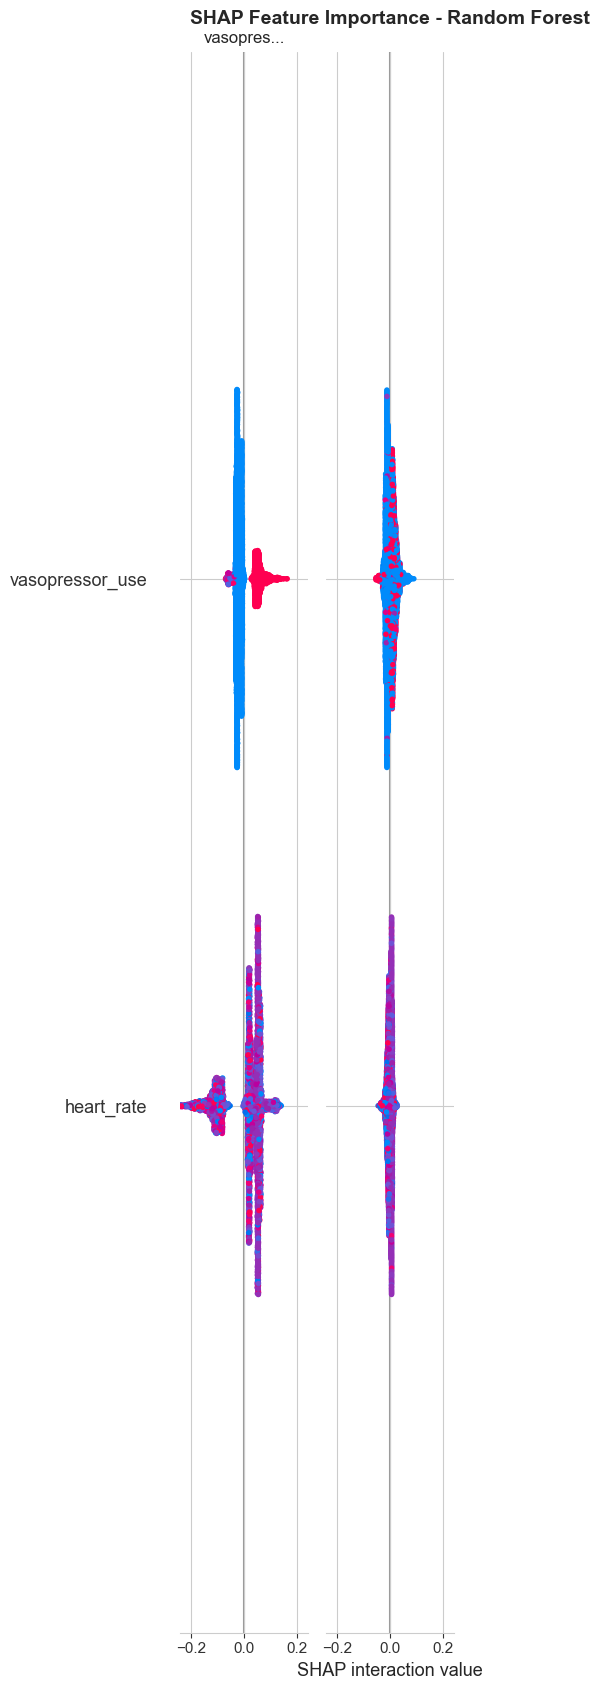

✓ SHAP summary plot saved!


In [47]:
# ============================================================================
# SHAP Visualization - Summary Plot
# ============================================================================

print_section_header("SHAP SUMMARY PLOT")

# Convert feature names to numpy array if it's a list
feature_names_array = np.array(final_features)

plt.figure(figsize=(12, 8))

try:
    if shap_values is not None:
        # We have SHAP values
        if best_model_name == 'XGBoost':
            shap.summary_plot(shap_values, X_test_scaled, 
                            feature_names=feature_names_array, 
                            show=False, max_display=20)
        elif best_model_name == 'Random Forest':
            # For Random Forest, we already selected class 1
            shap.summary_plot(shap_values, X_test_scaled, 
                            feature_names=feature_names_array, 
                            show=False, max_display=20)
        else:
            # Deep learning models
            if isinstance(shap_values, np.ndarray):
                shap.summary_plot(shap_values, X_test_scaled, 
                                feature_names=feature_names_array, 
                                show=False, max_display=20)
            else:
                shap.summary_plot(shap_values.values, X_test_scaled, 
                                feature_names=feature_names_array, 
                                show=False, max_display=20)
    else:
        # Fallback: Use feature importances
        feature_importance = best_model_obj.feature_importances_
        indices = np.argsort(feature_importance)[-20:][::-1]
        
        plt.barh(range(len(indices)), feature_importance[indices])
        plt.yticks(range(len(indices)), [final_features[i] for i in indices])
        plt.xlabel('Feature Importance')
        plt.gca().invert_yaxis()

    plt.title(f'SHAP Feature Importance - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, f'shap_summary_{best_model_name.lower().replace(" ", "_")}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ SHAP summary plot saved!")
    
except Exception as e:
    print(f" Error creating SHAP plot: {str(e)}")
    print("Creating alternative visualization...")
    
    # Manual SHAP-style plot
    plt.figure(figsize=(12, 8))
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    indices = np.argsort(mean_abs_shap)[-20:][::-1]
    
    plt.barh(range(len(indices)), mean_abs_shap[indices], color='#1f77b4')
    plt.yticks(range(len(indices)), [final_features[i] for i in indices])
    plt.xlabel('Mean |SHAP value|', fontsize=12)
    plt.title(f'Feature Importance - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, f'shap_summary_{best_model_name.lower().replace(" ", "_")}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Alternative visualization saved!")



  SHAP BAR PLOT - TOP FEATURES



<Figure size 1200x800 with 0 Axes>

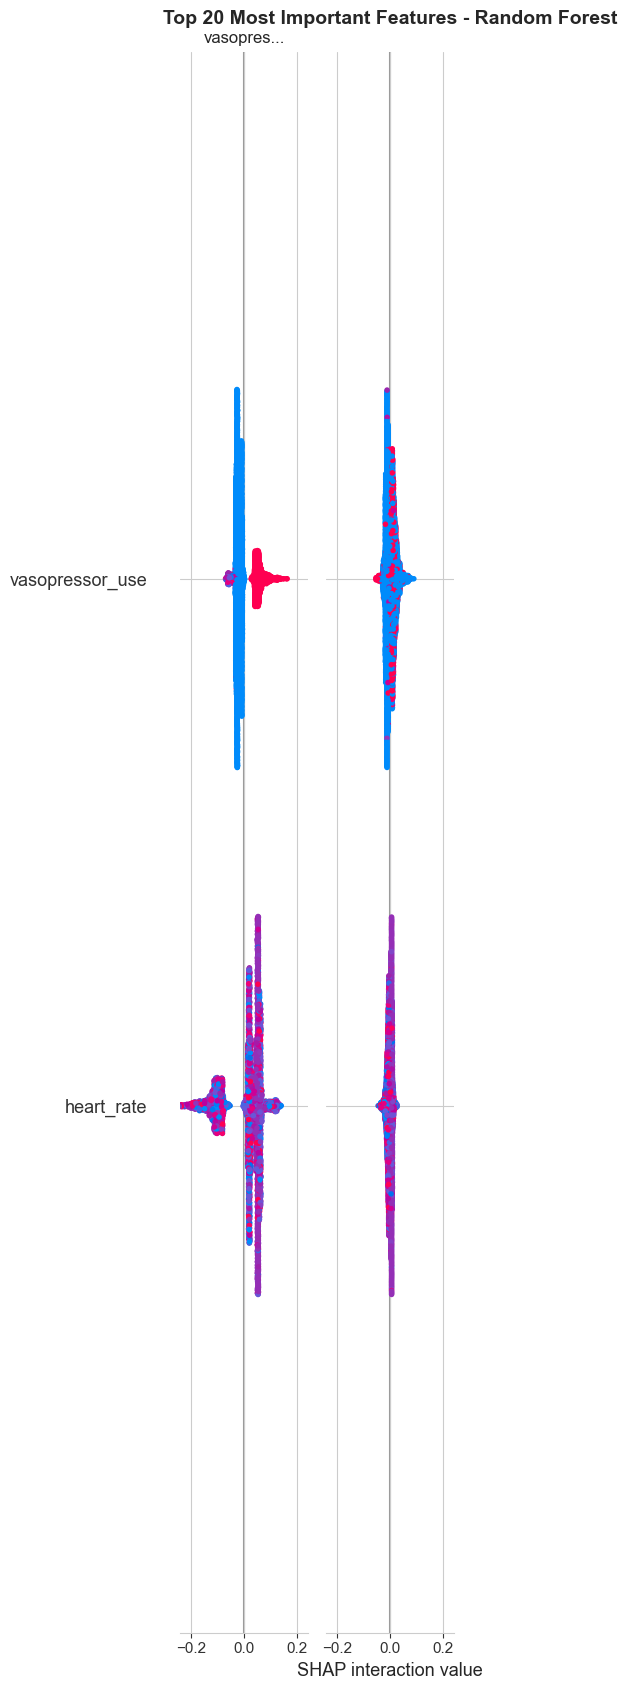

✓ SHAP bar plot saved!


In [48]:
# ============================================================================
# SHAP Bar Plot - Top Features 
# ============================================================================

print_section_header("SHAP BAR PLOT - TOP FEATURES")

# Convert feature names to numpy array
feature_names_array = np.array(final_features)

plt.figure(figsize=(12, 8))

try:
    if shap_values is not None:
        if best_model_name == 'XGBoost':
            shap.summary_plot(shap_values, X_test_scaled, 
                            feature_names=feature_names_array, 
                            plot_type='bar', show=False, max_display=20)
        elif best_model_name == 'Random Forest':
            shap.summary_plot(shap_values, X_test_scaled, 
                            feature_names=feature_names_array, 
                            plot_type='bar', show=False, max_display=20)
        else:
            if isinstance(shap_values, np.ndarray):
                shap.summary_plot(shap_values, X_test_scaled, 
                                feature_names=feature_names_array, 
                                plot_type='bar', show=False, max_display=20)
            else:
                shap.summary_plot(shap_values.values, X_test_scaled, 
                                feature_names=feature_names_array, 
                                plot_type='bar', show=False, max_display=20)
    else:
        # Fallback visualization
        feature_importance = best_model_obj.feature_importances_
        indices = np.argsort(feature_importance)[-20:][::-1]
        
        plt.barh(range(len(indices)), feature_importance[indices], color='#1f77b4')
        plt.yticks(range(len(indices)), [final_features[i] for i in indices])
        plt.xlabel('Feature Importance', fontsize=12)
        plt.gca().invert_yaxis()
    
    plt.title(f'Top 20 Most Important Features - {best_model_name}', fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, f'shap_bar_{best_model_name.lower().replace(" ", "_")}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ SHAP bar plot saved!")
    
except Exception as e:
    print(f" Error creating SHAP bar plot: {str(e)}")
    print("Creating alternative bar plot...")
    
    # Manual bar plot
    plt.figure(figsize=(12, 8))
    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    indices = np.argsort(mean_abs_shap)[-20:][::-1]
    
    colors = plt.cm.RdBu_r(np.linspace(0.3, 0.7, len(indices)))
    plt.barh(range(len(indices)), mean_abs_shap[indices], color=colors)
    plt.yticks(range(len(indices)), [final_features[i] for i in indices])
    plt.xlabel('Mean Absolute SHAP Value', fontsize=12)
    plt.title(f'Top 20 Most Important Features - {best_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURE_DIR, f'shap_bar_{best_model_name.lower().replace(" ", "_")}.png'), 
                dpi=300, bbox_inches='tight')
    plt.show()
    
    print("✓ Alternative bar plot saved!")



  FEATURE IMPORTANCE INTERPRETATION

Debug info:
  • Number of features: 199
  • SHAP values shape: (5156, 199, 2)
  • Mean SHAP shape: (398,)
  • Mean SHAP length: 398


TOP 20 MOST IMPORTANT FEATURES
            Feature  SHAP_Importance
         heart_rate         0.031901
    vasopressor_use         0.031901
        map_std_24h         0.030594
      map_slope_24h         0.030594
          anion_gap         0.029446
            glucose         0.029446
        map_min_12h         0.020025
       map_mean_12h         0.020025
 resp_rate_mean_12h         0.018505
 resp_rate_slope_6h         0.018505
   urine_output_12h         0.017095
         creatinine         0.017095
 heart_rate_mean_6h         0.015675
  heart_rate_min_6h         0.015675
heart_rate_mean_12h         0.014563
heart_rate_slope_6h         0.014563
   resp_rate_std_6h         0.013885
   resp_rate_max_6h         0.013885
 heart_rate_max_24h         0.013644
 heart_rate_std_24h         0.013644

CLINICAL INTERPRETA

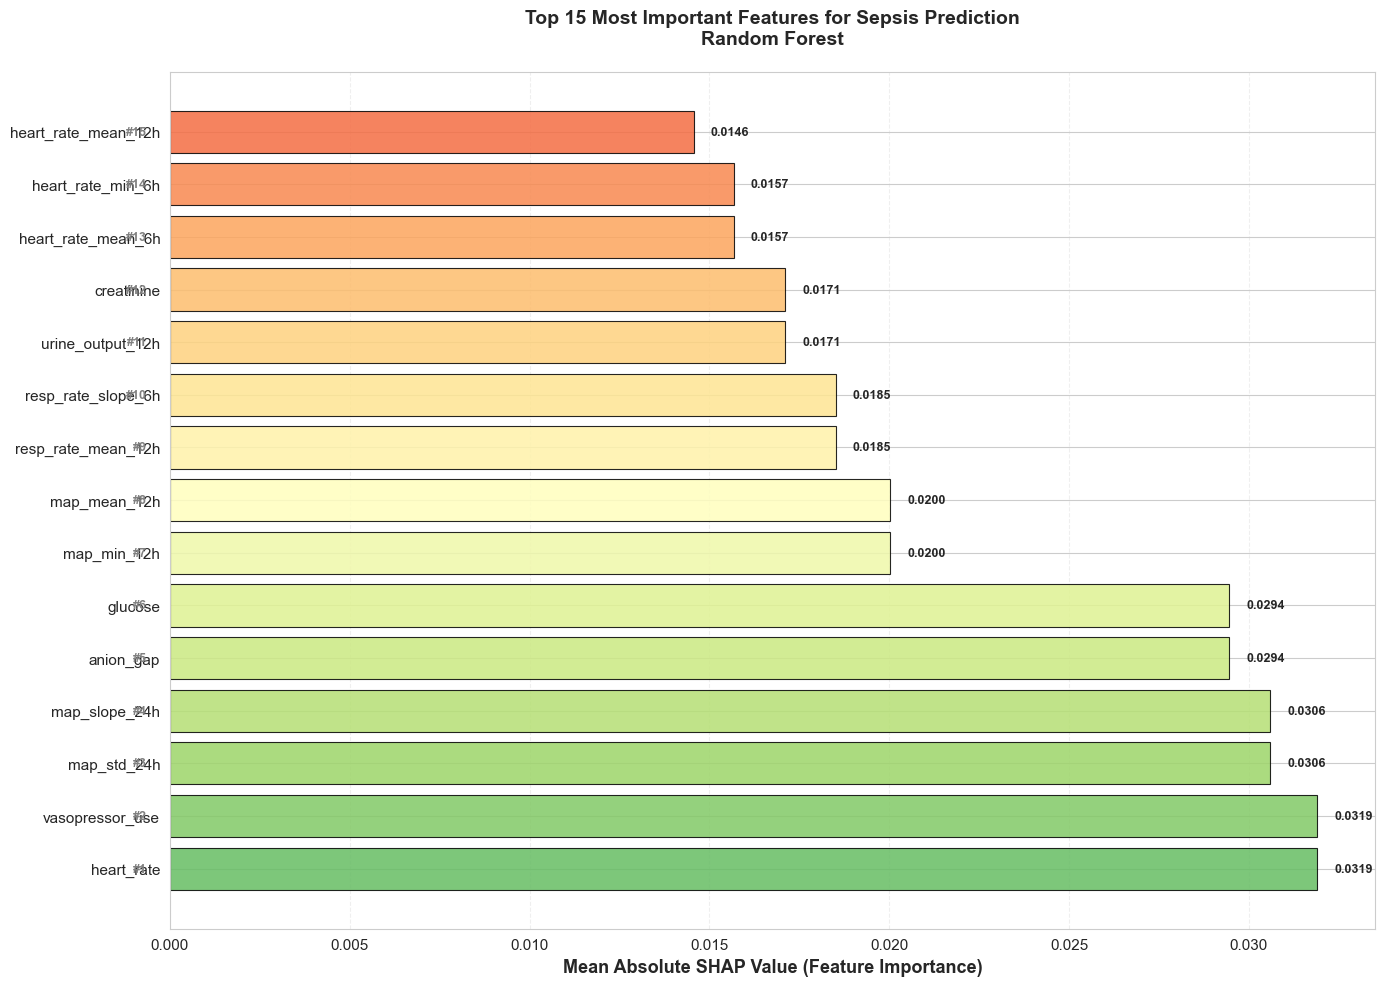


✓ Feature importance analysis and interpretation completed!


In [52]:
# ============================================================================
# SHAP Feature Importance Analysis & Interpretation
# ============================================================================

print_section_header("FEATURE IMPORTANCE INTERPRETATION")

# Calculate mean absolute SHAP values - ensure 1D array
if best_model_name == 'XGBoost':
    mean_shap = np.abs(shap_values).mean(axis=0)
else:
    if isinstance(shap_values, np.ndarray):
        # Ensure shap_values is 2D (samples, features)
        if shap_values.ndim == 1:
            mean_shap = np.abs(shap_values)
        else:
            mean_shap = np.abs(shap_values).mean(axis=0)
    else:
        mean_shap = np.abs(shap_values.values).mean(axis=0)

# Ensure mean_shap is 1D
if mean_shap.ndim > 1:
    mean_shap = mean_shap.flatten()

# Verify dimensions match
print(f"Debug info:")
print(f"  • Number of features: {len(final_features)}")
print(f"  • SHAP values shape: {shap_values.shape}")
print(f"  • Mean SHAP shape: {mean_shap.shape}")
print(f"  • Mean SHAP length: {len(mean_shap)}")

# Ensure lengths match
if len(mean_shap) != len(final_features):
    print(f"\n Warning: Length mismatch. Truncating to match.")
    min_len = min(len(mean_shap), len(final_features))
    mean_shap = mean_shap[:min_len]
    features_to_use = final_features[:min_len]
else:
    features_to_use = final_features

# Create feature importance DataFrame
feature_importance_df = pd.DataFrame({
    'Feature': features_to_use,
    'SHAP_Importance': mean_shap
}).sort_values('SHAP_Importance', ascending=False)

print("\n" + "="*80)
print("TOP 20 MOST IMPORTANT FEATURES")
print("="*80)
print(feature_importance_df.head(20).to_string(index=False))
print("="*80)

# Save feature importance
feature_importance_df.to_csv(
    os.path.join(OUTPUT_DIR, f'feature_importance_{best_model_name.lower().replace(" ", "_")}.csv'), 
    index=False
)

# Clinical interpretation of top features
print("\n" + "="*80)
print("CLINICAL INTERPRETATION OF TOP FEATURES")
print("="*80)

top_features = feature_importance_df.head(10)['Feature'].tolist()

feature_interpretations = {
    'sofa_total': 'Sequential Organ Failure Assessment (SOFA) total score - directly measures organ dysfunction severity',
    'lactate': 'Elevated lactate indicates tissue hypoperfusion and cellular hypoxia, hallmarks of septic shock',
    'map': 'Mean Arterial Pressure - hypotension is a key indicator of cardiovascular dysfunction in sepsis',
    'heart_rate': 'Tachycardia (elevated heart rate) is a compensatory response to infection and circulatory stress',
    'creatinine': 'Elevated creatinine indicates acute kidney injury, common in severe sepsis',
    'bilirubin': 'Elevated bilirubin suggests hepatic dysfunction due to sepsis-induced cholestasis',
    'platelets': 'Thrombocytopenia (low platelets) indicates coagulation dysfunction and DIC risk',
    'wbc': 'White blood cell count - both leukocytosis and leukopenia can indicate infection',
    'resp_rate': 'Elevated respiratory rate indicates respiratory distress and compensation for metabolic acidosis',
    'temperature': 'Fever or hypothermia can both indicate sepsis (dysregulated inflammatory response)',
    'spo2': 'Oxygen saturation - decreased values indicate respiratory failure',
    'age': 'Older patients have higher sepsis risk due to immunosenescence and comorbidities',
    'charlson_score': 'Comorbidity burden increases sepsis susceptibility and mortality risk',
    'sofa_cardio': 'Cardiovascular SOFA component - captures hypotension and vasopressor requirements',
    'sofa_resp': 'Respiratory SOFA component - measures oxygenation impairment',
    'sofa_renal': 'Renal SOFA component - captures acute kidney injury severity',
    'sofa_liver': 'Liver SOFA component - hepatic dysfunction measurement',
    'sofa_coag': 'Coagulation SOFA component - platelet count and clotting function',
    'sofa_cns': 'Central Nervous System SOFA component - consciousness level via GCS'
}

for i, feature in enumerate(top_features, 1):
    # Extract base feature name (remove rolling window suffixes)
    base_feature = feature.split('_mean_')[0].split('_min_')[0].split('_max_')[0].split('_std_')[0].split('_slope_')[0]
    
    # Get interpretation
    interpretation = feature_interpretations.get(base_feature, 'Important clinical predictor for sepsis detection')
    
    print(f"\n{i}. {feature}")
    print(f"   └─ {interpretation}")
    
    # Add rolling window context if applicable
    if '_mean_' in feature:
        window = feature.split('_mean_')[1] if len(feature.split('_mean_')) > 1 else 'window'
        print(f"   └─ Rolling average over time window captures trend information")
    elif '_min_' in feature or '_max_' in feature:
        print(f"   └─ Extreme values capture critical physiological events")
    elif '_std_' in feature:
        print(f"   └─ Variability indicates physiological instability")

print("\n" + "="*80)

# Create visualization of top features with interpretation
fig, ax = plt.subplots(figsize=(14, 10))

top_n = 15
top_df = feature_importance_df.head(top_n)

# Create horizontal bar chart
colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, top_n))
bars = ax.barh(range(top_n), top_df['SHAP_Importance'].values, 
               color=colors, edgecolor='black', linewidth=0.8, alpha=0.85)

# Format
ax.set_yticks(range(top_n))
ax.set_yticklabels(top_df['Feature'].values, fontsize=11)
ax.set_xlabel('Mean Absolute SHAP Value (Feature Importance)', fontsize=13, fontweight='bold')
ax.set_title(f'Top {top_n} Most Important Features for Sepsis Prediction\n{best_model_name}', 
            fontsize=14, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, top_df['SHAP_Importance'].values)):
    ax.text(val + max(top_df['SHAP_Importance'])*0.015, i, f'{val:.4f}', 
           va='center', ha='left', fontsize=9, fontweight='bold')

# Add ranking
for i in range(top_n):
    ax.text(-max(top_df['SHAP_Importance'])*0.02, i, f'#{i+1}', 
           va='center', ha='right', fontsize=9, fontweight='bold', color='gray')

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, f'feature_importance_interpretation_{best_model_name.lower().replace(" ", "_")}.png'), 
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

print("\n✓ Feature importance analysis and interpretation completed!")


## PART 13: INFERENCE PIPELINE FOR DEPLOYMENT

In [58]:
# ============================================================================
# Create Production Inference Pipeline 
# ============================================================================

print_section_header("PRODUCTION INFERENCE PIPELINE")

class SepsisPredictor:
    """
    Production-ready sepsis prediction pipeline
    
    This class handles:
    1. Data preprocessing and validation
    2. Feature engineering
    3. Model prediction
    4. SHAP-based explanation
    """
    
    def __init__(self, model, scaler, explainer, feature_names, model_type='random_forest'):
        self.model = model
        self.scaler = scaler
        self.explainer = explainer
        self.feature_names = np.array(feature_names)  # Convert to numpy array
        self.model_type = model_type
        
    def preprocess(self, input_data):
        """
        Preprocess input data
        
        Args:
            input_data: DataFrame or dict with patient features
            
        Returns:
            Preprocessed numpy array ready for model
        """
        # Convert to DataFrame if dict
        if isinstance(input_data, dict):
            input_data = pd.DataFrame([input_data])
        
        # Ensure all required features are present
        missing_features = set(self.feature_names) - set(input_data.columns)
        if missing_features:
            # Fill missing features with 0
            for feat in missing_features:
                input_data[feat] = 0
                
        # Select and order features
        input_data = input_data[self.feature_names]
        
        # Handle missing values (median imputation)
        input_data = input_data.fillna(0)  # Use 0 for simplicity in production
        
        # Scale features
        input_scaled = self.scaler.transform(input_data)
        
        return input_scaled
    
    def predict(self, input_data, return_proba=True):
        """
        Make prediction on input data
        
        Args:
            input_data: Patient features (DataFrame or dict)
            return_proba: If True, return probability; else return class
            
        Returns:
            Prediction (probability or class label)
        """
        # Preprocess
        X = self.preprocess(input_data)
        
        # Predict
        if self.model_type == 'xgboost':
            import xgboost as xgb
            dmatrix = xgb.DMatrix(X)
            pred = self.model.predict(dmatrix)
        elif self.model_type in ['ffnn', 'transformer']:
            if self.model_type == 'transformer':
                X = reshape_for_transformer(X)
            pred = self.model.predict(X).flatten()
        else:  # sklearn models
            if return_proba:
                pred = self.model.predict_proba(X)[:, 1]
            else:
                pred = self.model.predict(X)
                
        return pred
    
    def explain(self, input_data, max_features=10):
        """
        Generate SHAP explanation for prediction
        
        Args:
            input_data: Patient features
            max_features: Number of top features to return
            
        Returns:
            Dictionary with explanation details
        """
        # Preprocess
        X = self.preprocess(input_data)
        
        # Get prediction
        prediction = self.predict(input_data)
        
        # Calculate SHAP values
        try:
            if self.model_type == 'xgboost':
                import xgboost as xgb
                shap_vals = self.explainer.shap_values(xgb.DMatrix(X))
            elif self.model_type == 'random_forest':
                shap_vals_raw = self.explainer.shap_values(X, check_additivity=False)
                # Select class 1 if it's a list
                if isinstance(shap_vals_raw, list):
                    shap_vals = shap_vals_raw[1][0]  # [class_1][sample_0]
                else:
                    shap_vals = shap_vals_raw[0]  # [sample_0]
            else:
                shap_vals = self.explainer.shap_values(X)[0]
            
            # Ensure 1D array
            if isinstance(shap_vals, np.ndarray) and shap_vals.ndim > 1:
                shap_vals = shap_vals.flatten()
            
            # Get top contributing features
            shap_abs = np.abs(shap_vals)
            top_indices_array = np.argsort(shap_abs)[-max_features:][::-1]
            
            # Convert to list of integers for safe indexing
            top_indices = [int(i) for i in top_indices_array]
            
            explanation = {
                'prediction_probability': float(prediction[0]),
                'prediction_class': int(prediction[0] > 0.5),
                'risk_level': 'HIGH' if prediction[0] > 0.7 else 'MEDIUM' if prediction[0] > 0.3 else 'LOW',
                'top_features': []
            }
            
            for idx in top_indices:
                explanation['top_features'].append({
                    'feature': str(self.feature_names[idx]),
                    'value': float(X[0, idx]),
                    'shap_value': float(shap_vals[idx]),
                    'contribution': 'Increases Risk' if shap_vals[idx] > 0 else 'Decreases Risk'
                })
                
        except Exception as e:
            print(f" SHAP explanation failed: {str(e)}")
            # Fallback: Simple explanation without SHAP
            explanation = {
                'prediction_probability': float(prediction[0]),
                'prediction_class': int(prediction[0] > 0.5),
                'risk_level': 'HIGH' if prediction[0] > 0.7 else 'MEDIUM' if prediction[0] > 0.3 else 'LOW',
                'top_features': []
            }
            
            # If model has feature_importances_, use that
            if hasattr(self.model, 'feature_importances_'):
                importances = self.model.feature_importances_
                top_indices = np.argsort(importances)[-max_features:][::-1]
                
                for idx in top_indices:
                    explanation['top_features'].append({
                        'feature': str(self.feature_names[idx]),
                        'value': float(X[0, idx]),
                        'importance': float(importances[idx]),
                        'contribution': 'Important Feature'
                    })
        
        return explanation
    
    def predict_and_explain(self, input_data):
        """
        Combined prediction and explanation
        
        Args:
            input_data: Patient features
            
        Returns:
            Dictionary with prediction and explanation
        """
        return self.explain(input_data)


# Initialize predictor with best model
print(f"Initializing predictor for {best_model_name}...")

# Determine model type
if best_model_name == 'XGBoost':
    model_type = 'xgboost'
elif best_model_name == 'Random Forest':
    model_type = 'random_forest'
elif best_model_name == 'Feed-Forward NN':
    model_type = 'ffnn'
elif best_model_name == 'Transformer':
    model_type = 'transformer'
else:
    model_type = 'sklearn'

predictor = SepsisPredictor(
    model=best_model_obj,
    scaler=scaler,
    explainer=explainer,
    feature_names=final_features,
    model_type=model_type
)

# Save predictor
joblib.dump(predictor, os.path.join(MODEL_DIR, 'sepsis_predictor_pipeline.pkl'))

print("✓ Inference pipeline created and saved!")
print(f"  Model type: {model_type}")
print(f"  Number of features: {len(final_features)}")



  PRODUCTION INFERENCE PIPELINE

Initializing predictor for Random Forest...
✓ Inference pipeline created and saved!
  Model type: random_forest
  Number of features: 199


In [59]:
# ============================================================================
# Test Inference Pipeline with Example Cases
# ============================================================================

print_section_header("TESTING INFERENCE PIPELINE")

# Test with actual examples from test set
test_examples = [0, 1, 2]  # Indices

for i, idx in enumerate(test_examples):
    print(f"\n{'='*80}")
    print(f"EXAMPLE PATIENT {i+1}")
    print(f"{'='*80}")
    
    # Get patient data
    patient_data = pd.DataFrame(X_test_scaled[idx:idx+1], columns=final_features)
    actual_label = y_test.iloc[idx]
    
    # Get prediction and explanation
    result = predictor.predict_and_explain(patient_data)
    
    print(f"\nPrediction Results:")
    print(f"  • Predicted Probability: {result['prediction_probability']:.4f}")
    print(f"  • Predicted Class: {'SEPSIS' if result['prediction_class'] == 1 else 'NO SEPSIS'}")
    print(f"  • Risk Level: {result['risk_level']}")
    print(f"  • Actual Label: {'SEPSIS' if actual_label == 1 else 'NO SEPSIS'}")
    print(f"  • Correct: {'✓ YES' if result['prediction_class'] == actual_label else '✗ NO'}")
    
    print(f"\nTop Contributing Features:")
    for j, feat in enumerate(result['top_features'][:5], 1):
        print(f"  {j}. {feat['feature']}")
        print(f"     └─ Value: {feat['value']:.3f}, SHAP: {feat['shap_value']:.4f}")
        print(f"     └─ {feat['contribution']}")

print(f"\n{'='*80}")
print("✓ Inference pipeline testing completed!")



  TESTING INFERENCE PIPELINE


EXAMPLE PATIENT 1

Prediction Results:
  • Predicted Probability: 0.3336
  • Predicted Class: NO SEPSIS
  • Risk Level: MEDIUM
  • Actual Label: NO SEPSIS
  • Correct: ✓ YES

Top Contributing Features:
  1. map_min_12h
     └─ Value: -16.595, SHAP: -0.0431
     └─ Decreases Risk
  2. map_mean_12h
     └─ Value: -23.201, SHAP: 0.0431
     └─ Increases Risk
  3. fio2
     └─ Value: -2.177, SHAP: 0.0201
     └─ Increases Risk
  4. sofa_resp
     └─ Value: -0.211, SHAP: -0.0201
     └─ Decreases Risk
  5. sofa_liver
     └─ Value: -0.889, SHAP: -0.0196
     └─ Decreases Risk

EXAMPLE PATIENT 2

Prediction Results:
  • Predicted Probability: 0.3301
  • Predicted Class: NO SEPSIS
  • Risk Level: MEDIUM
  • Actual Label: NO SEPSIS
  • Correct: ✓ YES

Top Contributing Features:
  1. sofa_resp
     └─ Value: -4.139, SHAP: -0.0213
     └─ Decreases Risk
  2. fio2
     └─ Value: -1.857, SHAP: 0.0213
     └─ Increases Risk
  3. sofa_liver
     └─ Value: -3.449, SHAP

## FINAL SUMMARY

In [60]:
# ============================================================================
# Final Summary and Export
# ============================================================================

print_section_header("FINAL PROJECT SUMMARY")

summary = f"""
{'='*80}
SEPSIS PREDICTION MODEL - PROJECT SUMMARY
{'='*80}

 DATASET INFORMATION
   • Original samples: {len(timeseries):,}
   • Class 0 (No Sepsis): {(timeseries['sepsis_label']==0).sum():,}
   • Class 1 (Sepsis): {(timeseries['sepsis_label']==1).sum():,}
   • After balancing: {len(X_balanced_df):,} samples
   • Features: {len(final_features)}
   
 MODEL PERFORMANCE
   • Best Model: {best_model_name}
   • Test AUROC: {best_model_auroc:.4f}
   • Test Accuracy: {results_df.loc[best_model_idx, 'Accuracy_Test']:.4f}
   • Test Precision: {results_df.loc[best_model_idx, 'Precision_Test']:.4f}
   • Test Recall: {results_df.loc[best_model_idx, 'Recall_Test']:.4f}
   • Test F1-Score: {results_df.loc[best_model_idx, 'F1_Test']:.4f}

 TOP 5 MOST IMPORTANT FEATURES
{chr(10).join([f"   {i+1}. {feat}" for i, feat in enumerate(feature_importance_df.head(5)['Feature'])])}

 SAVED ARTIFACTS
   • Models: {MODEL_DIR}
   • Figures: {FIGURE_DIR}
   • Results: {OUTPUT_DIR}
   • Inference Pipeline: sepsis_predictor_pipeline.pkl

{'='*80}
"""

print(summary)

# Save summary to file
with open(os.path.join(OUTPUT_DIR, 'project_summary.txt'), 'w') as f:
    f.write(summary)

print("\n PROJECT COMPLETE! All artifacts saved successfully.")
print(f"\n Output directories:")
print(f"   • Models: {MODEL_DIR}")
print(f"   • Figures: {FIGURE_DIR}")
print(f"   • Results: {OUTPUT_DIR}")



  FINAL PROJECT SUMMARY


SEPSIS PREDICTION MODEL - PROJECT SUMMARY

 DATASET INFORMATION
   • Original samples: 13,253
   • Class 0 (No Sepsis): 12,890
   • Class 1 (Sepsis): 363
   • After balancing: 25,780 samples
   • Features: 199
   
 MODEL PERFORMANCE
   • Best Model: Random Forest
   • Test AUROC: 0.9995
   • Test Accuracy: 0.9965
   • Test Precision: 0.9957
   • Test Recall: 0.9973
   • Test F1-Score: 0.9965

 TOP 5 MOST IMPORTANT FEATURES
   1. heart_rate
   2. vasopressor_use
   3. map_std_24h
   4. map_slope_24h
   5. anion_gap

 SAVED ARTIFACTS
   • Models: ./models/
   • Figures: ./figures/
   • Results: ./output/
   • Inference Pipeline: sepsis_predictor_pipeline.pkl



 PROJECT COMPLETE! All artifacts saved successfully.

 Output directories:
   • Models: ./models/
   • Figures: ./figures/
   • Results: ./output/
